# NFHS-5 District Health Indicators Analysis

This notebook converts the markdown findings into a runnable analysis of
`output/data/raw_nfhs_5_district_health_indicators.csv`, with supporting
checks against the cleaned facility-health join output.

**Objective:** understand what the third dataset contains, where joins can
fail, and which district-level health indicators show useful planning
patterns for the hackathon app.


## Notebook plan

- Load the raw NFHS-5-style district health table and the cleaned
  facility-health table.
- Profile the row grain, keys, sample sizes, missingness, and join traps.
- Visualize join strategy distribution and major health-indicator groups.
- Build a transparent district `health_need_score` from selected adverse
  and access indicators.
- Surface state/district patterns and correlations that are useful for
  planning, while keeping the district-level nature of the data explicit.


In [1]:
from __future__ import annotations

from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "output" / "data" / "raw_nfhs_5_district_health_indicators.csv").exists():
        ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate output/data/raw_nfhs_5_district_health_indicators.csv from cwd")

DATA_DIR = ROOT / "output" / "data"
HEALTH_CSV = DATA_DIR / "raw_nfhs_5_district_health_indicators.csv"
CLEANED_CSV = DATA_DIR / "facility_health_cleaned.csv"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 130
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

health_raw = pd.read_csv(HEALTH_CSV)
facilities = pd.read_csv(CLEANED_CSV)

health = health_raw.copy()
health["district_clean"] = health["district_name"].astype(str).str.strip()
health["state_clean"] = health["state_ut"].astype(str).str.strip()

id_cols = {"district_name", "state_ut", "district_clean", "state_clean"}
for col in health.columns:
    if col not in id_cols:
        health[col] = pd.to_numeric(health[col], errors="coerce")

def normalize_text(value) -> str:
    if pd.isna(value):
        return ""
    value = str(value).strip().lower().replace("&", "and")
    return re.sub(r"[^a-z0-9]+", "", value)

def normalize_state(value) -> str:
    aliases = {
        "nctofdelhi": "delhi",
        "jammuandkashmir": "jammukashmir",
        "jammukashmir": "jammukashmir",
        "maharastra": "maharashtra",
        "maharashtra": "maharashtra",
        "odisha": "odisha",
        "orissa": "odisha",
        "dadraandnagarhavelianddamananddiu": "dadranagarhavelidamandiu",
    }
    raw = normalize_text(value)
    return aliases.get(raw, raw)

health["health_key"] = health["state_clean"].map(normalize_state) + "|" + health["district_clean"].map(normalize_text)
health.head(3)


/var/folders/n0/qltlkrkj3j7fvwdbktn46z5h0000gn/T/ipykernel_74916/2266440899.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  health["health_key"] = health["state_clean"].map(normalize_state) + "|" + health["district_clean"].map(normalize_text)


,district_name,state_ut,households_surveyed,women_15_49_interviewed,men_15_54_interviewed,female_population_age_6_years_and_above_ever_schooled_pct,population_below_age_15_years_pct,sex_ratio_total_f_per_1000_m,sex_ratio_at_birth_5y_f_per_1000_m,child_u5_whose_birth_was_civil_reg_pct,deaths_in_the_last_3_years_civil_reg_pct,hh_electricity_pct,hh_improved_water_pct,hh_use_improved_sanitation_pct,households_using_clean_fuel_for_cooking_pct,households_using_iodized_salt_pct,hh_member_covered_health_insurance_pct,child_5y_who_attended_pre_primary_school_during_the_school_pct,women_age_15_49_who_are_literate_pct,women_age_15_49_with_10_or_more_years_of_schooling_pct,w20_24_married_before_age_18_years_pct,births_in_the_5_years_preceding_the_survey_that_are_birth_3_pct,w15_19_who_were_already_mothers_or_pregnant_at_the_time_of_pct,w15_24_who_use_menstrual_hygiene_pct,fp_cm_w15_49_any_method_pct,fp_cm_w15_49_modern_method_pct,fp_cm_w15_49_f_steril_pct,fp_cm_w15_49_m_steril_pct,fp_cm_w15_49_iud_pct,fp_cm_w15_49_pill_pct,fp_cm_w15_49_condom_pct,fp_cm_w15_49_injectables_pct,fp_unmet_total_cm_w15_49_7_pct,fp_unmet_spacing_cm_w15_49_7_pct,health_worker_ever_talked_to_female_non_users_about_family_pct,current_users_ever_told_about_side_effects_of_current_metho_pct,mothers_who_had_an_anc_visit_in_the_first_trimester_lb5y_pct,mothers_who_had_at_least_4_anc_visits_lb5y_pct,mothers_whose_last_birth_was_protected_against_neo_tetanus_pct,mothers_who_consumed_ifa_for_100_days_or_more_when_they_wer_pct,...,child_u6m_exclusively_breastfed_pct,child_6_8m_receiving_solid_or_semi_solid_food_and_breastmil_pct,breastfeeding_child_6_23m_receiving_an_adequate_diet16_17_pct,non_breastfeeding_child_6_23m_receiving_an_adequate_diet16_pct,total_child_6_23m_receiving_an_adequate_diet16_17_pct,child_u5_who_are_stunted_height_for_age_18_pct,child_u5_who_are_wasted_weight_for_height_18_pct,child_u5_who_are_severe_wasted_weight_for_height_19_pct,child_u5_who_are_underweight_weight_for_age_18_pct,child_u5_who_are_overweight_weight_for_height_20_pct,women_age_15_49_years_whose_bmi_bmi_is_underweight_bmi_lt_1_pct,women_age_15_49_years_who_are_overweight_obese_bmi_gte_25_0_pct,women_age_15_49_years_who_have_high_risk_whr_gte_0_85_pct,child_6_59m_who_are_anaemic_lt_11_0_g_dl_22_pct,non_pregnant_w15_49_who_are_anaemic_lt_12_0_g_dl_22_pct,pregnant_w15_49_who_are_anaemic_lt_11_0_g_dl_22_pct,all_w15_49_who_are_anaemic_pct,all_w15_19_who_are_anaemic_pct,women_age_15_years_and_above_with_high_141_160_mg_dl_blood_pct,w15_plus_with_very_high_gt_160_mg_dl_blood_sugar_pct,w15_plus_with_high_or_very_high_gt_140_mg_dl_blood_sugar_or_pct,m15_plus_with_high_141_160_mg_dl_blood_sugar_pct,men_age_15_years_and_above_with_very_high_gt_160_mg_dl_bloo_pct,m15_plus_with_high_or_very_high_gt_140_mg_dl_blood_sugar_or_pct,w15_plus_with_mildly_high_bp_sys_140_159_mmhg_and_or_dia_90_pct,w15_plus_with_moderately_or_severely_high_bp_sys_gte_160_mm_pct,w15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct,m15_plus_with_mildly_high_bp_sys_140_159_mmhg_and_or_dia_90_pct,m15_plus_with_moderately_or_severely_high_bp_sys_gte_160_mm_pct,m15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct,women_age_30_49_years_ever_undergone_a_cervical_screen_pct,women_age_30_49_years_ever_undergone_a_breast_exam_pct,women_age_30_49_years_ever_undergone_an_oral_cancer_exam_pct,w15_plus_who_use_any_kind_of_tobacco_pct,m15_plus_who_use_any_kind_of_tobacco_pct,w15_plus_who_consume_alcohol_pct,m15_plus_who_consume_alcohol_pct,district_clean,state_clean,health_key
0,Nicobars,Andaman & Nicobar Islands,882.0,764.0,125.0,78.0,23.0,973.0,927.0,98.0,83.2,97.9,98.8,83.5,56.9,99.4,2.7,NaN,87.5,53.5,11.4,0.0,1.8,100.0,65.3,57.2,46.4,0.0,2.7,2.0,4.9,1.2,9.5,3.3,40.4,49.4,62.8,71.7,78.0,72.6,...,NaN,NaN,NaN,NaN,NaN,21.6,15.7,7.8,24.6,1.5,8.2,39.1,62.5,37.7,38.4,NaN,38.3,48.0,7.4,3.9,13.1,9.6,4.4,15.4,23.2,8.5,35.4,32.9,11.1,47.0,13.4,13.2,5.4,63.5,76.8,29.6,64.5,Nicobars,Andaman & Nicobar Islands,andamanandnicobari

## 1. High-level table profile

The raw health file is district-grain: one row per district/state pair.
It should be used as geographic context, not as a direct facility-level
measurement. When joined to facilities, every facility in a district
inherits the same district summary values.


,Metric,Value
0,Rows,706
1,Columns,109
2,States/UTs,36
3,Duplicate state + district keys,0
4,Columns with missing values,0
5,District names with trailing spaces,704
6,Median households surveyed,908
7,Median women 15-49 interviewed,1020
8,Median men 15-54 interviewed,145


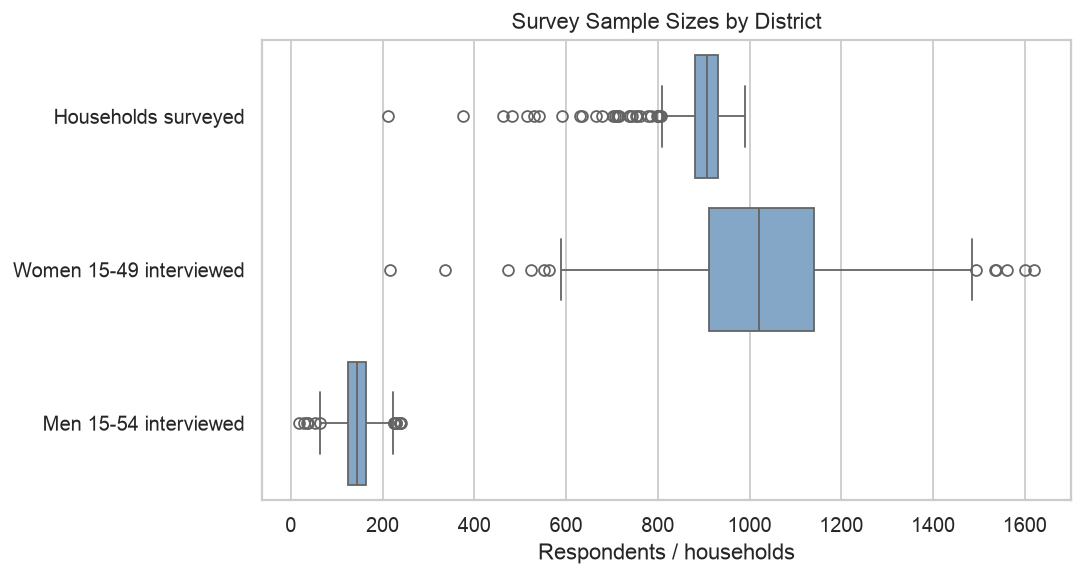

In [2]:
profile = pd.DataFrame(
    {
        "Metric": [
            "Rows",
            "Columns",
            "States/UTs",
            "Duplicate state + district keys",
            "Columns with missing values",
            "District names with trailing spaces",
            "Median households surveyed",
            "Median women 15-49 interviewed",
            "Median men 15-54 interviewed",
        ],
        "Value": [
            len(health_raw),
            health_raw.shape[1],
            health["state_clean"].nunique(),
            health_raw.duplicated(["state_ut", "district_name"]).sum(),
            int((health_raw.notna().mean() < 1).sum()),
            int(health_raw["district_name"].astype(str).str.endswith(" ").sum()),
            int(health["households_surveyed"].median()),
            int(health["women_15_49_interviewed"].median()),
            int(health["men_15_54_interviewed"].median()),
        ],
    }
)

display(profile)

sample_cols = [
    "households_surveyed",
    "women_15_49_interviewed",
    "men_15_54_interviewed",
]
sample_long = health[sample_cols].rename(
    columns={
        "households_surveyed": "Households surveyed",
        "women_15_49_interviewed": "Women 15-49 interviewed",
        "men_15_54_interviewed": "Men 15-54 interviewed",
    }
).melt(var_name="Sample", value_name="Respondents")

fig, ax = plt.subplots(figsize=(8.5, 4.6))
sns.boxplot(data=sample_long, y="Sample", x="Respondents", ax=ax, color="#79a7d3")
ax.set_title("Survey Sample Sizes by District")
ax.set_xlabel("Respondents / households")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## 2. Join diagnostics and mapping traps

The health table has no pincode, facility ID, latitude, or longitude.
The practical bridge is:

`facility address_zipOrPostcode` -> extracted six-digit PIN ->
`pincode_bridge.csv` -> normalized state/district -> NFHS `state_ut` +
`district_name`.

The current cleaned facility output preserves join strategy and uncertainty
fields, which should stay visible in any user-facing app.


,join_strategy,facility_rows
0,pincode_district_state_exact,9032
1,pincode_only_no_health_match,397
2,facility_city_state_fallback,301
3,no_valid_pincode,150
4,pincode_district_state_fuzzy,131
5,unjoined,66


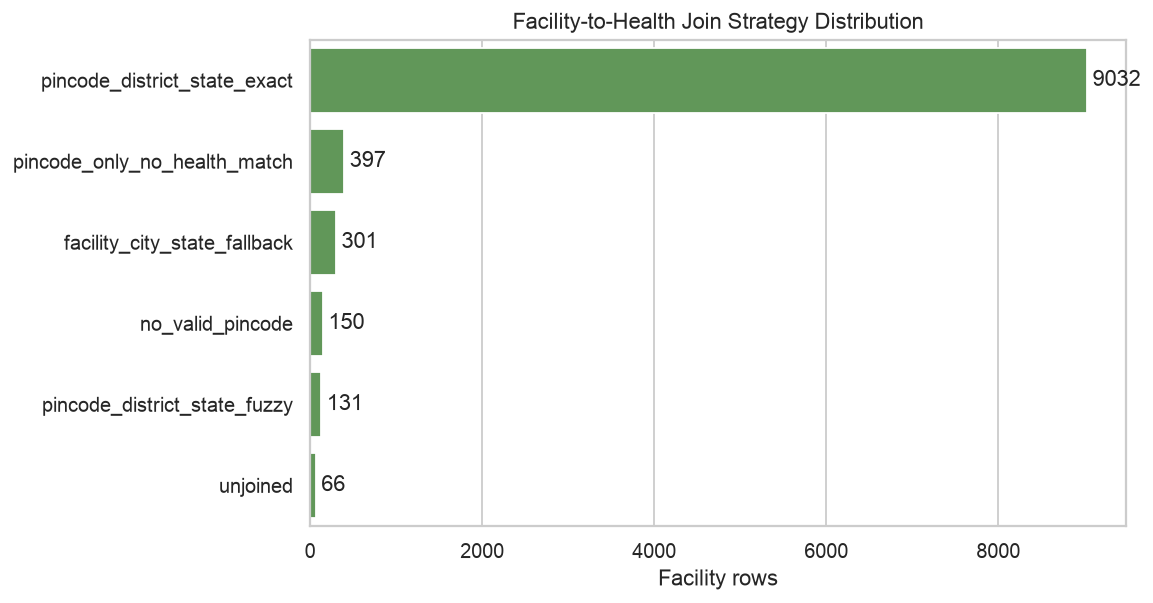

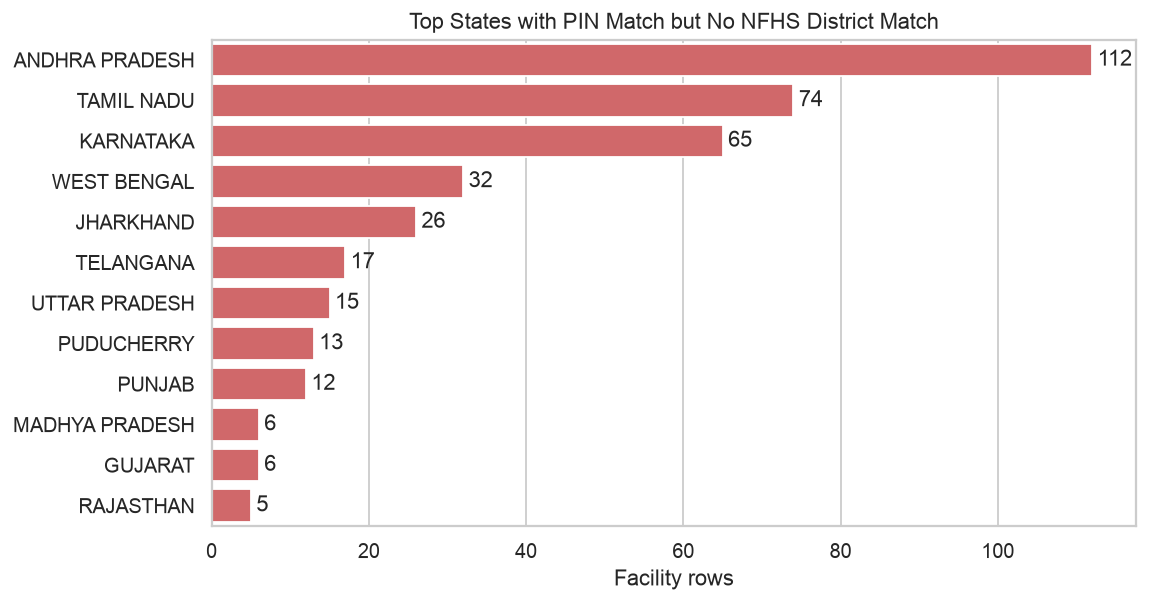

In [3]:
join_counts = (
    facilities["join_strategy"]
    .value_counts(dropna=False)
    .rename_axis("join_strategy")
    .reset_index(name="facility_rows")
)
display(join_counts)

fig, ax = plt.subplots(figsize=(9, 4.8))
sns.barplot(data=join_counts, y="join_strategy", x="facility_rows", ax=ax, color="#59a14f")
ax.set_title("Facility-to-Health Join Strategy Distribution")
ax.set_xlabel("Facility rows")
ax.set_ylabel("")
for container in ax.containers:
    ax.bar_label(container, padding=3, fmt="%d")
plt.tight_layout()
plt.show()

no_health = facilities[facilities["join_strategy"].eq("pincode_only_no_health_match")].copy()
no_health_by_state = (
    no_health["pincode_primary_state"]
    .value_counts()
    .rename_axis("pincode_primary_state")
    .reset_index(name="facility_rows")
    .head(12)
)

fig, ax = plt.subplots(figsize=(9, 4.8))
sns.barplot(data=no_health_by_state, y="pincode_primary_state", x="facility_rows", ax=ax, color="#e15759")
ax.set_title("Top States with PIN Match but No NFHS District Match")
ax.set_xlabel("Facility rows")
ax.set_ylabel("")
for container in ax.containers:
    ax.bar_label(container, padding=3, fmt="%d")
plt.tight_layout()
plt.show()


**Key join trap:** the raw NFHS table uses `Maharastra`, while the pincode
data uses `MAHARASHTRA`. Without an alias, a large number of Maharashtra
facility rows fail the health join even when pincode data is present.

District naming also needs a crosswalk for renamed or newly split districts:
examples include Gurgaon/Gurugram, Bangalore/Bengaluru Urban,
Darjiling/Darjeeling, Haora/Howrah, and newer Andhra Pradesh or Tamil Nadu
postal districts that do not appear as separate NFHS-5 rows.


In [4]:
state_values = pd.Series(sorted(health_raw["state_ut"].unique()), name="raw_state_ut")
display(state_values.to_frame().query("raw_state_ut.str.contains('Mahar|Lakshadweep', regex=True)", engine="python"))

maharashtra_gap = facilities[
    facilities["pincode_primary_state"].astype(str).str.contains("MAHAR", na=False)
    & facilities["join_strategy"].eq("pincode_only_no_health_match")
]
print(f"Maharashtra facility rows missing health indicators due to state/district join mismatch: {len(maharashtra_gap):,}")


,raw_state_ut
0,Lakshadweep
19,Maharastra


Maharashtra facility rows missing health indicators due to state/district join mismatch: 0


## 3. Indicator groups and selected summary statistics

Most columns ending in `_pct` are percentages. Exceptions to watch:
survey counts, sex ratios per 1,000 males, and out-of-pocket expenditure
per public-facility delivery.

The table covers household conditions, insurance, education, fertility and
family planning, maternal care, delivery care, child immunization, child
illness, infant feeding, nutrition, anaemia, NCD markers, cancer screening,
tobacco, and alcohol.


In [5]:
key_indicators = {
    "Health insurance coverage": "hh_member_covered_health_insurance_pct",
    "Women literate": "women_age_15_49_who_are_literate_pct",
    "Institutional births": "institutional_birth_5y_pct",
    "Skilled birth attendance": "births_attended_by_skilled_hp_5y_10_pct",
    "C-section deliveries": "births_delivered_by_csection_5y_pct",
    "Children fully vaccinated": "child_12_23m_fully_vaccinated_based_on_information_from_vax_pct",
    "Child adequate diet 6-23m": "total_child_6_23m_receiving_an_adequate_diet16_17_pct",
    "U5 stunted": "child_u5_who_are_stunted_height_for_age_18_pct",
    "U5 wasted": "child_u5_who_are_wasted_weight_for_height_18_pct",
    "U5 underweight": "child_u5_who_are_underweight_weight_for_age_18_pct",
    "Women 15-49 anaemic": "all_w15_49_who_are_anaemic_pct",
    "Women high BP": "w15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct",
    "Men high BP": "m15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct",
    "Women high/very high blood sugar": "w15_plus_with_high_or_very_high_gt_140_mg_dl_blood_sugar_or_pct",
    "Men high/very high blood sugar": "m15_plus_with_high_or_very_high_gt_140_mg_dl_blood_sugar_or_pct",
    "Cervical screening": "women_age_30_49_years_ever_undergone_a_cervical_screen_pct",
    "Breast exam": "women_age_30_49_years_ever_undergone_a_breast_exam_pct",
    "Oral cancer exam": "women_age_30_49_years_ever_undergone_an_oral_cancer_exam_pct",
    "Women tobacco": "w15_plus_who_use_any_kind_of_tobacco_pct",
    "Men tobacco": "m15_plus_who_use_any_kind_of_tobacco_pct",
    "Women alcohol": "w15_plus_who_consume_alcohol_pct",
    "Men alcohol": "m15_plus_who_consume_alcohol_pct",
}

rows = []
for label, col in key_indicators.items():
    s = health[col]
    min_idx, max_idx = s.idxmin(), s.idxmax()
    rows.append(
        {
            "Indicator": label,
            "Mean": round(s.mean(), 1),
            "Median": round(s.median(), 1),
            "P10": round(s.quantile(0.10), 1),
            "P90": round(s.quantile(0.90), 1),
            "Min district": f"{health.loc[min_idx, 'district_clean']}, {health.loc[min_idx, 'state_clean']} ({s.loc[min_idx]:.1f})",
            "Max district": f"{health.loc[max_idx, 'district_clean']}, {health.loc[max_idx, 'state_clean']} ({s.loc[max_idx]:.1f})",
        }
    )
indicator_summary = pd.DataFrame(rows)
display(indicator_summary)


,Indicator,Mean,Median,P10,P90,Min district,Max district
0,Health insurance coverage,40.2,35.7,13.2,72.2,"South Andaman, Andaman & Nicobar Islands (1.2)","Barmer, Rajasthan (97.8)"
1,Women literate,74.3,75.1,57.7,89.0,"Jhabua, Madhya Pradesh (38.6)","Kottayam, Kerala (99.7)"
2,Institutional births,88.7,92.2,73.8,99.4,"Mon, Nagaland (21.4)","South Goa, Goa (100.0)"
3,Skilled birth attendance,89.6,92.3,77.6,99.0,"Mon, Nagaland (30.9)","Sri Potti Sriramulu Nello, Andhra Pradesh (100.0)"
4,C-section deliveries,22.8,18.6,6.6,46.8,"Mon, Nagaland (1.4)","Karimnagar, Telangana (82.4)"
5,Children fully vaccinated,82.6,83.6,69.4,94.0,"Ukhrul, Manipur (45.0)","Kupwara, Jammu & Kashmir (100.0)"
6,Child adequate diet 6-23m,11.9,10.6,4.0,22.0,"Mahesana, Gujarat (0.0)","East Garo Hills, Meghalaya (43.9)"
7,U5 stunted,33.5,32.9,23.1,45.1,"Jagatsinghapur, Odisha (13.2)","Pashchimi Singhbhum, Jharkhand (60.6)"
8,U5 wasted,18.5,18.1,10.3,27.3,"North District, Sikkim (4.5)","Karimganj, Assam (48.0)"
9,U5 underweight,29.5,29.3,16.8,42.3,"South District, Sikkim (7.2)","Pashchimi Singhbhum, Jharkhand (62.4)"


## 4. Visual trends across major health domains

These plots are unweighted district-level distributions. They are useful
for comparing district patterns, but not for producing official national
estimates.


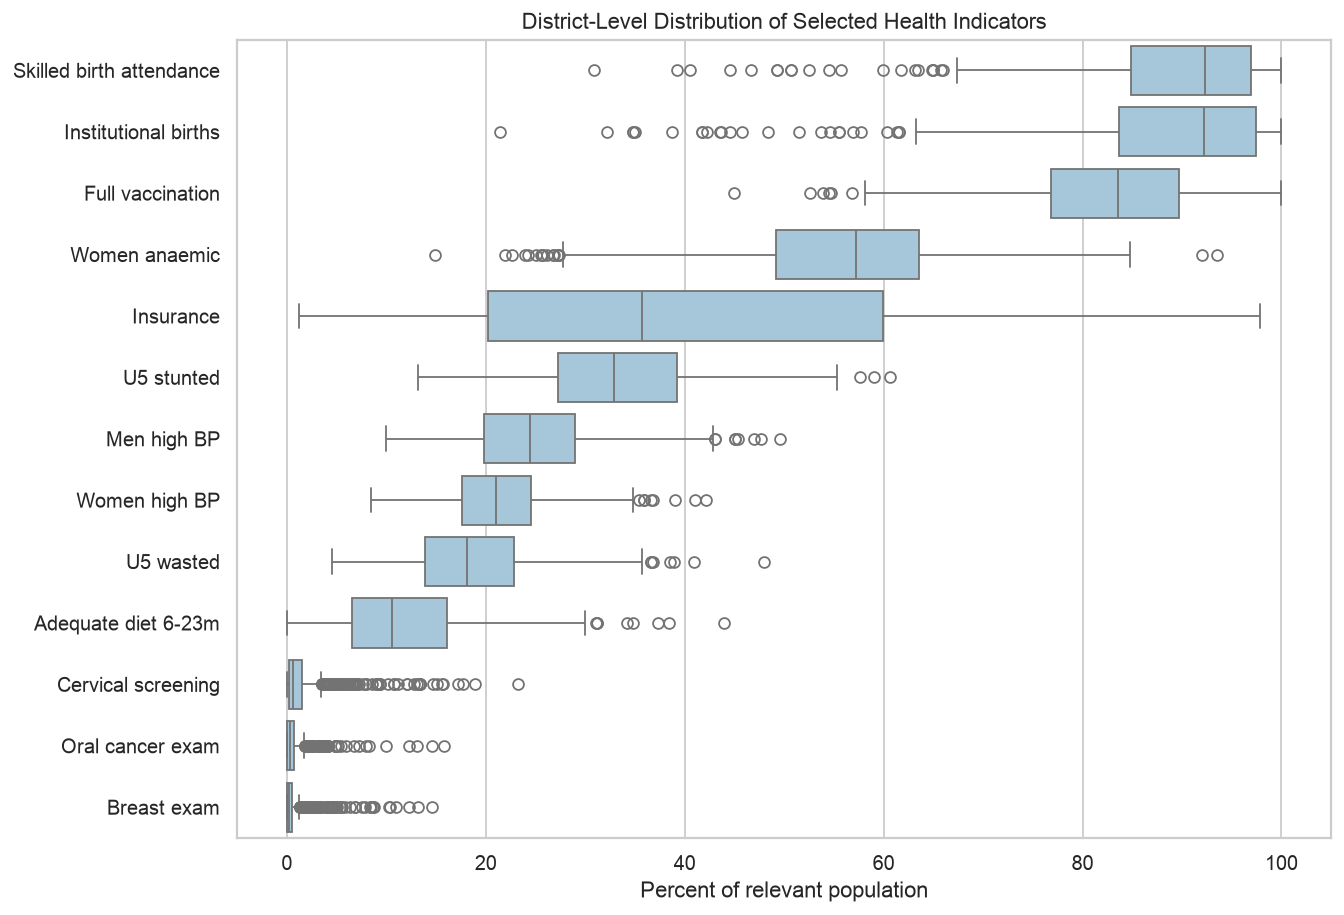

In [6]:
domain_cols = {
    "Insurance": "hh_member_covered_health_insurance_pct",
    "Institutional births": "institutional_birth_5y_pct",
    "Skilled birth attendance": "births_attended_by_skilled_hp_5y_10_pct",
    "Full vaccination": "child_12_23m_fully_vaccinated_based_on_information_from_vax_pct",
    "Adequate diet 6-23m": "total_child_6_23m_receiving_an_adequate_diet16_17_pct",
    "U5 stunted": "child_u5_who_are_stunted_height_for_age_18_pct",
    "U5 wasted": "child_u5_who_are_wasted_weight_for_height_18_pct",
    "Women anaemic": "all_w15_49_who_are_anaemic_pct",
    "Women high BP": "w15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct",
    "Men high BP": "m15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct",
    "Cervical screening": "women_age_30_49_years_ever_undergone_a_cervical_screen_pct",
    "Breast exam": "women_age_30_49_years_ever_undergone_a_breast_exam_pct",
    "Oral cancer exam": "women_age_30_49_years_ever_undergone_an_oral_cancer_exam_pct",
}
domain_long = health[list(domain_cols.values())].rename(columns={v: k for k, v in domain_cols.items()}).melt(
    var_name="Indicator", value_name="District percent"
)

order = (
    domain_long.groupby("Indicator")["District percent"]
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(10.5, 7.2))
sns.boxplot(data=domain_long, y="Indicator", x="District percent", order=order, ax=ax, color="#9ecae1")
ax.set_title("District-Level Distribution of Selected Health Indicators")
ax.set_xlabel("Percent of relevant population")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


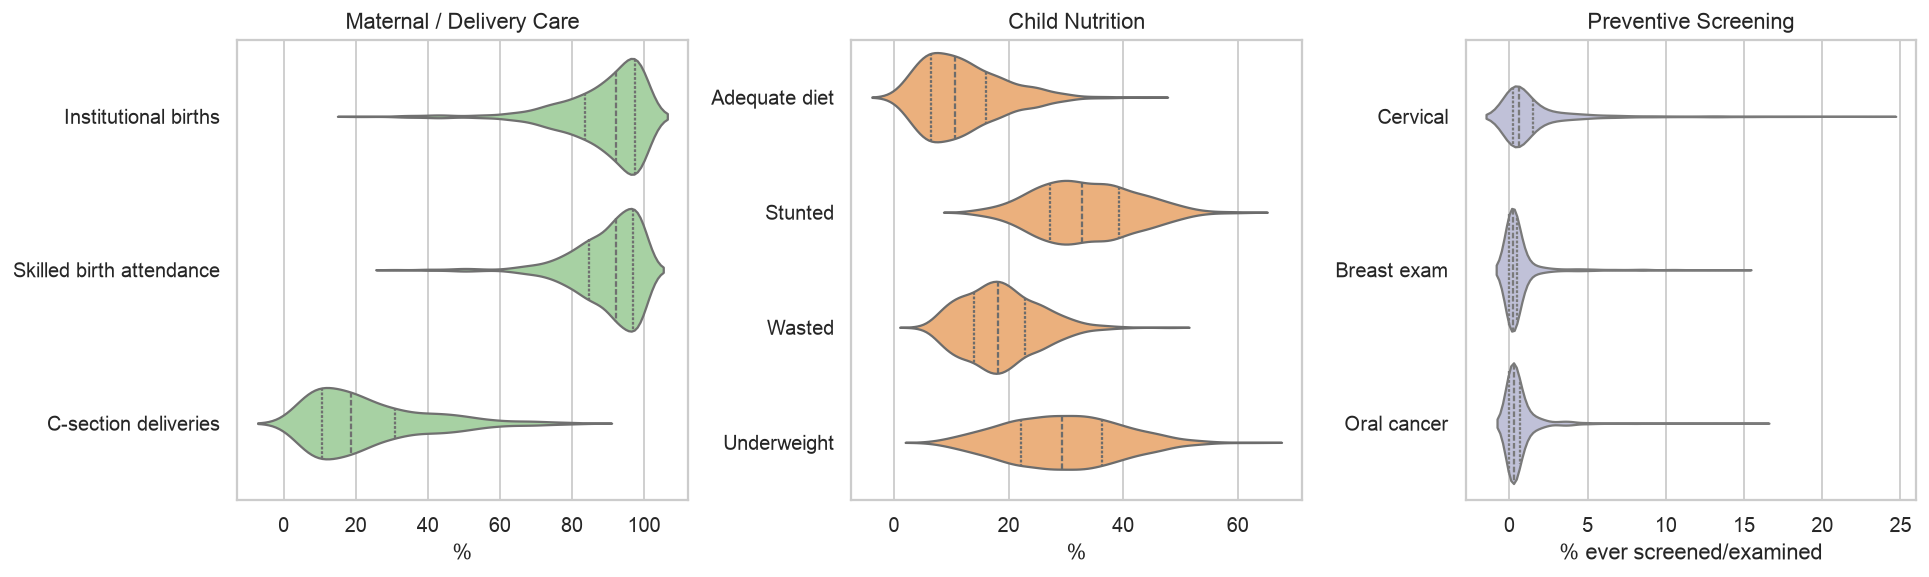

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

maternal = health[
    [
        "institutional_birth_5y_pct",
        "births_attended_by_skilled_hp_5y_10_pct",
        "births_delivered_by_csection_5y_pct",
    ]
].rename(
    columns={
        "institutional_birth_5y_pct": "Institutional births",
        "births_attended_by_skilled_hp_5y_10_pct": "Skilled birth attendance",
        "births_delivered_by_csection_5y_pct": "C-section deliveries",
    }
).melt(var_name="Indicator", value_name="District percent")
sns.violinplot(data=maternal, y="Indicator", x="District percent", ax=axes[0], color="#a1d99b", inner="quartile")
axes[0].set_title("Maternal / Delivery Care")
axes[0].set_xlabel("%")
axes[0].set_ylabel("")

nutrition = health[
    [
        "total_child_6_23m_receiving_an_adequate_diet16_17_pct",
        "child_u5_who_are_stunted_height_for_age_18_pct",
        "child_u5_who_are_wasted_weight_for_height_18_pct",
        "child_u5_who_are_underweight_weight_for_age_18_pct",
    ]
].rename(
    columns={
        "total_child_6_23m_receiving_an_adequate_diet16_17_pct": "Adequate diet",
        "child_u5_who_are_stunted_height_for_age_18_pct": "Stunted",
        "child_u5_who_are_wasted_weight_for_height_18_pct": "Wasted",
        "child_u5_who_are_underweight_weight_for_age_18_pct": "Underweight",
    }
).melt(var_name="Indicator", value_name="District percent")
sns.violinplot(data=nutrition, y="Indicator", x="District percent", ax=axes[1], color="#fdae6b", inner="quartile")
axes[1].set_title("Child Nutrition")
axes[1].set_xlabel("%")
axes[1].set_ylabel("")

screening = health[
    [
        "women_age_30_49_years_ever_undergone_a_cervical_screen_pct",
        "women_age_30_49_years_ever_undergone_a_breast_exam_pct",
        "women_age_30_49_years_ever_undergone_an_oral_cancer_exam_pct",
    ]
].rename(
    columns={
        "women_age_30_49_years_ever_undergone_a_cervical_screen_pct": "Cervical",
        "women_age_30_49_years_ever_undergone_a_breast_exam_pct": "Breast exam",
        "women_age_30_49_years_ever_undergone_an_oral_cancer_exam_pct": "Oral cancer",
    }
).melt(var_name="Indicator", value_name="District percent")
sns.violinplot(data=screening, y="Indicator", x="District percent", ax=axes[2], color="#bcbddc", inner="quartile")
axes[2].set_title("Preventive Screening")
axes[2].set_xlabel("% ever screened/examined")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()


## 5. Health-need score

The score below mirrors the cleaned dataset's approach: percentile-rank
adverse indicators upward and access indicators downward, then average the
components. It is intentionally transparent and bounded, but it is a
planning proxy, not an official risk model.


/var/folders/n0/qltlkrkj3j7fvwdbktn46z5h0000gn/T/ipykernel_74916/2272448525.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  health["health_need_score"] = pd.concat(score_parts, axis=1).mean(axis=1).clip(0, 1)


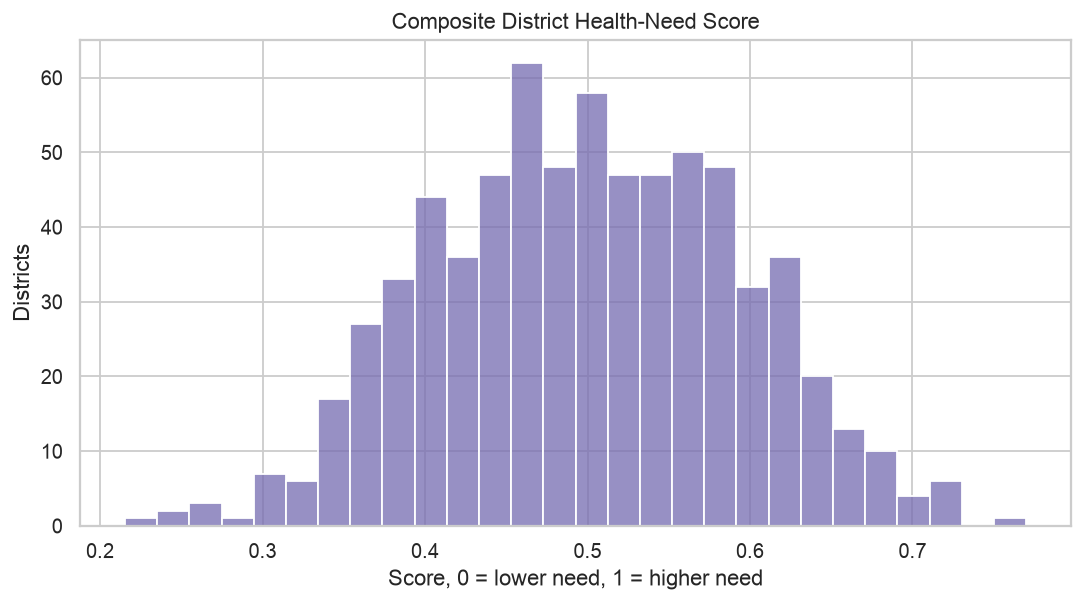

,district_clean,state_clean,health_need_score,all_w15_49_who_are_anaemic_pct,institutional_birth_5y_pct,hh_member_covered_health_insurance_pct,w15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct,m15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct
78,Katihar,Bihar,0.770,68.400000,66.900000,8.400000,17.000000,17.800000
690,Uttar Dinajpur,West Bengal,0.730,72.400000,76.900000,21.000000,16.300000,23.800000
234,Pakur,Jharkhand,0.730,79.700000,64.600000,52.500000,17.100000,20.200000
597,Unakoti,Tripura,0.725,67.900000,71.500000,28.000000,21.000000,22.100000
165,Kheda,Gujarat,0.715,76.100000,95.200000,32.200000,24.000000,24.500000
440,Kendujhar,Odisha,0.714,69.200000,80.400000,43.300000,24.100000,25.100000
155,Tapi,Gujarat,0.711,77.400000,92.900000,42.300000,25.200000,28.000000
416,Wokha,Nagaland,0.705,30.900000,43.600000,20.600000,24.300000,35.700000
72,Sitamarhi,Bihar,0.704,61.700000,64.400000,20.700000,17.800000,17.900000
104,Jamui,Bihar,0.701,75.200000,73.400000,14.300000,12.600000,14.800000


In [8]:
high_bad = [
    "all_w15_49_who_are_anaemic_pct",
    "w15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct",
    "m15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct",
    "w15_plus_with_high_or_very_high_gt_140_mg_dl_blood_sugar_or_pct",
    "m15_plus_with_high_or_very_high_gt_140_mg_dl_blood_sugar_or_pct",
]
low_bad = [
    "hh_member_covered_health_insurance_pct",
    "women_age_15_49_who_are_literate_pct",
    "institutional_birth_5y_pct",
    "births_attended_by_skilled_hp_5y_10_pct",
    "women_age_30_49_years_ever_undergone_a_cervical_screen_pct",
    "women_age_30_49_years_ever_undergone_a_breast_exam_pct",
    "women_age_30_49_years_ever_undergone_an_oral_cancer_exam_pct",
]

score_parts = [health[col].rank(pct=True) for col in high_bad]
score_parts.extend([1 - health[col].rank(pct=True) for col in low_bad])
health["health_need_score"] = pd.concat(score_parts, axis=1).mean(axis=1).clip(0, 1)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
sns.histplot(health["health_need_score"], bins=28, ax=ax, color="#756bb1")
ax.set_title("Composite District Health-Need Score")
ax.set_xlabel("Score, 0 = lower need, 1 = higher need")
ax.set_ylabel("Districts")
plt.tight_layout()
plt.show()

top_need = health.sort_values("health_need_score", ascending=False)[
    [
        "district_clean",
        "state_clean",
        "health_need_score",
        "all_w15_49_who_are_anaemic_pct",
        "institutional_birth_5y_pct",
        "hh_member_covered_health_insurance_pct",
        "w15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct",
        "m15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct",
    ]
].head(12)
display(top_need.style.format({"health_need_score": "{:.3f}"}))


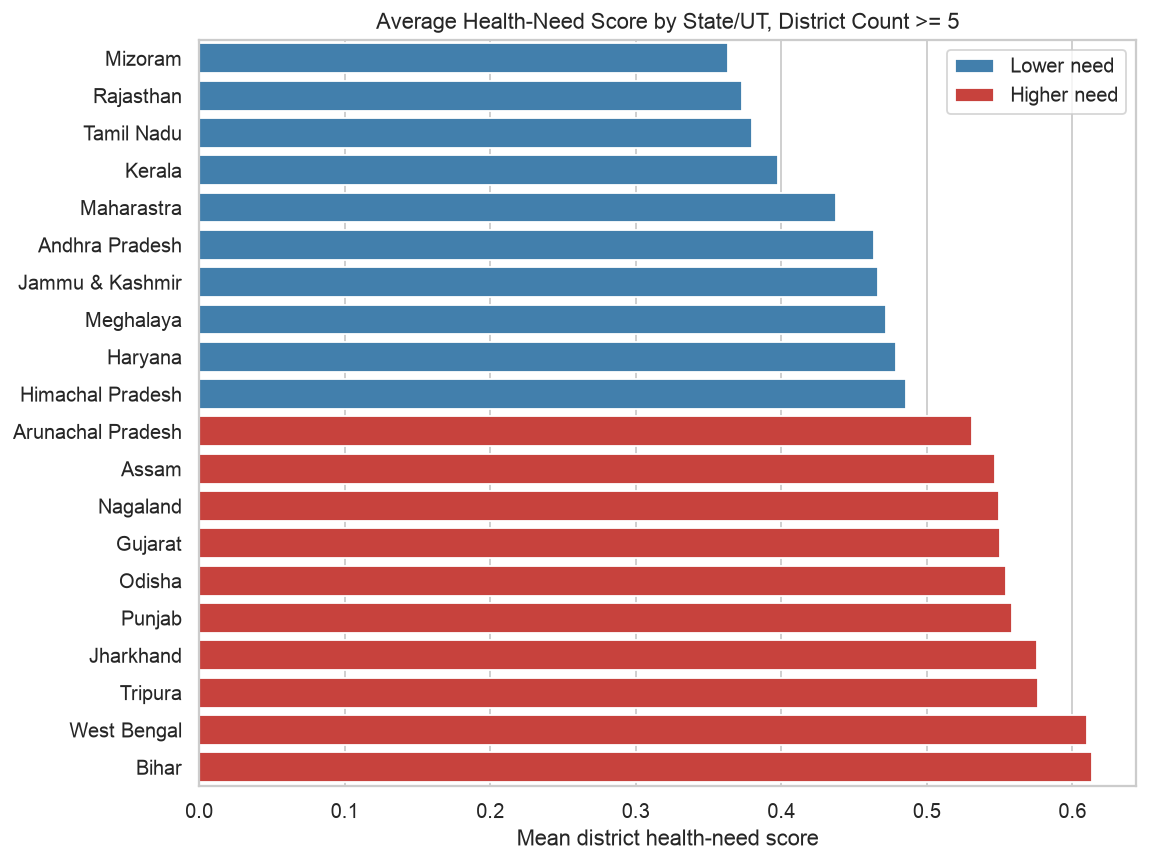

,state_clean,districts,health_need_score,anaemia,institutional_births,insurance,women_high_bp,men_high_bp
0,Bihar,38,0.613,64.7,77.8,14.1,15.436842,17.878947
1,West Bengal,19,0.610,71.5,92.0,28.9,20.457895,20.705263
2,Tripura,8,0.576,67.0,88.2,34.0,19.987500,21.600000
3,Jharkhand,24,0.576,66.3,76.2,51.8,17.241667,21.987500
4,Punjab,22,0.558,58.8,94.9,25.0,30.877273,37.259091
5,Odisha,30,0.555,64.3,92.4,48.3,22.006667,25.060000
6,Gujarat,33,0.551,64.6,93.1,40.6,20.184848,20.081818
7,Nagaland,11,0.549,29.2,43.3,21.1,22.672727,30.109091
8,Assam,33,0.547,65.7,85.1,61.0,19.296970,21.330303
9,Arunachal Pradesh,20,0.531,38.9,80.0,28.3,24.970000,33.420000


In [9]:
state_need = (
    health.groupby("state_clean")
    .agg(
        districts=("district_clean", "size"),
        health_need_score=("health_need_score", "mean"),
        anaemia=("all_w15_49_who_are_anaemic_pct", "mean"),
        institutional_births=("institutional_birth_5y_pct", "mean"),
        insurance=("hh_member_covered_health_insurance_pct", "mean"),
        women_high_bp=("w15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct", "mean"),
        men_high_bp=("m15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct", "mean"),
    )
    .query("districts >= 5")
    .sort_values("health_need_score", ascending=False)
    .reset_index()
)

state_plot = pd.concat([state_need.head(10), state_need.tail(10)]).drop_duplicates("state_clean")
state_plot["group"] = np.where(
    state_plot["health_need_score"] >= state_need["health_need_score"].median(),
    "Higher need",
    "Lower need",
)

fig, ax = plt.subplots(figsize=(9, 6.8))
sns.barplot(
    data=state_plot.sort_values("health_need_score", ascending=True),
    y="state_clean",
    x="health_need_score",
    hue="group",
    dodge=False,
    palette={"Higher need": "#de2d26", "Lower need": "#3182bd"},
    ax=ax,
)
ax.set_title("Average Health-Need Score by State/UT, District Count >= 5")
ax.set_xlabel("Mean district health-need score")
ax.set_ylabel("")
ax.legend(title="")
plt.tight_layout()
plt.show()

display(state_need.head(10).style.format({"health_need_score": "{:.3f}", "anaemia": "{:.1f}", "institutional_births": "{:.1f}", "insurance": "{:.1f}"}))


## 6. Correlations worth noticing

These correlations are descriptive. They help identify planning gradients
and clusters of need, but they do not establish causality.


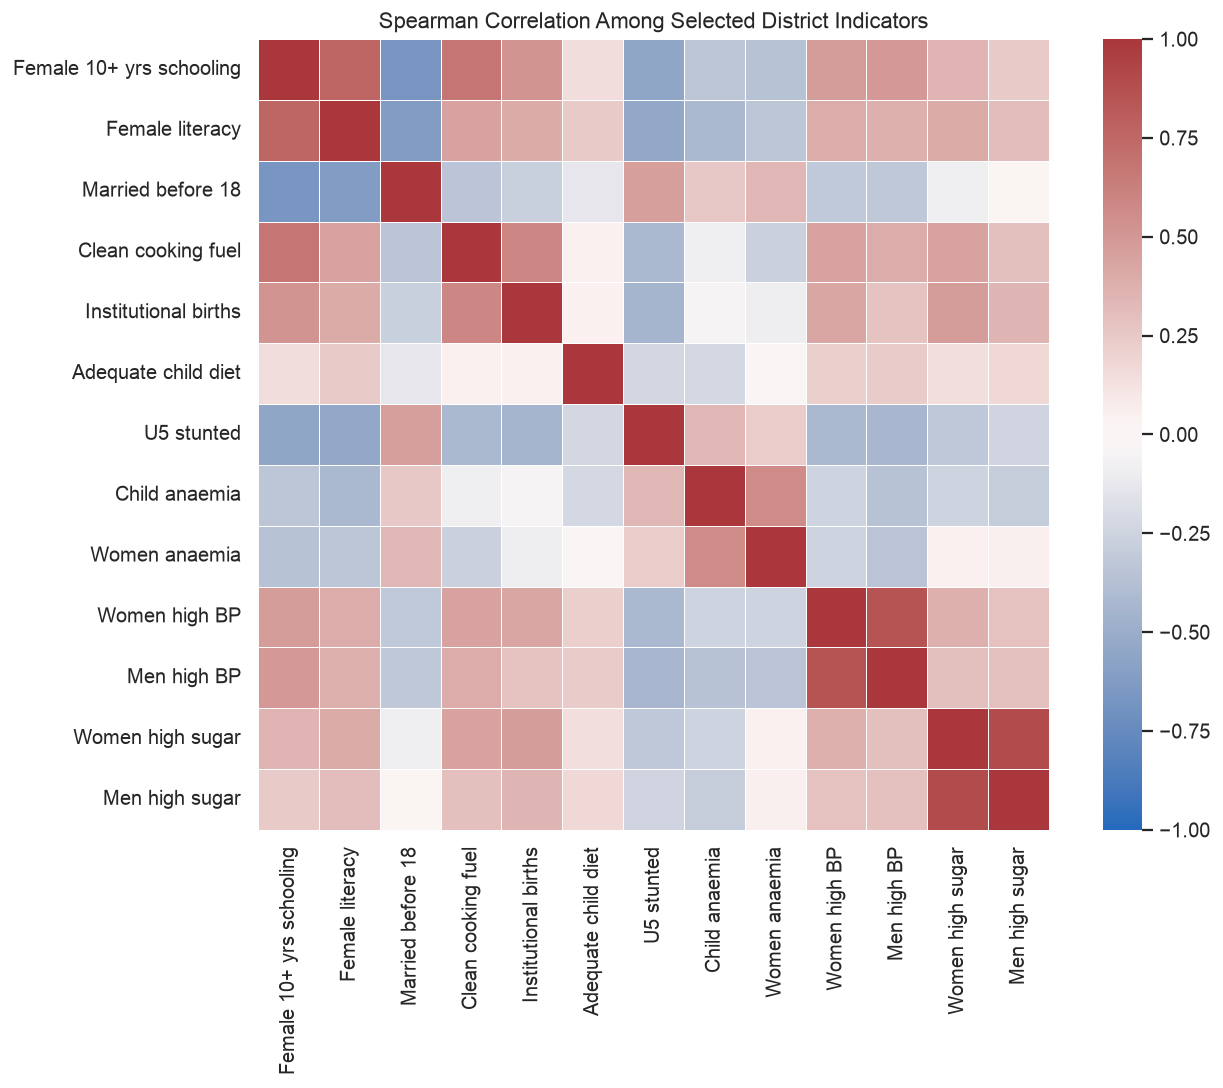

,Pair,Pearson,Spearman
0,Female 10+ yrs schooling vs married before 18,-0.65,-0.67
1,Clean cooking fuel vs institutional births,0.53,0.59
2,Women's anaemia vs child anaemia,0.65,0.56
3,Women high BP vs men high BP,0.86,0.86
4,Women high sugar vs men high sugar,0.91,0.90


In [10]:
corr_cols = {
    "Female 10+ yrs schooling": "women_age_15_49_with_10_or_more_years_of_schooling_pct",
    "Female literacy": "women_age_15_49_who_are_literate_pct",
    "Married before 18": "w20_24_married_before_age_18_years_pct",
    "Clean cooking fuel": "households_using_clean_fuel_for_cooking_pct",
    "Institutional births": "institutional_birth_5y_pct",
    "Adequate child diet": "total_child_6_23m_receiving_an_adequate_diet16_17_pct",
    "U5 stunted": "child_u5_who_are_stunted_height_for_age_18_pct",
    "Child anaemia": "child_6_59m_who_are_anaemic_lt_11_0_g_dl_22_pct",
    "Women anaemia": "all_w15_49_who_are_anaemic_pct",
    "Women high BP": "w15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct",
    "Men high BP": "m15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct",
    "Women high sugar": "w15_plus_with_high_or_very_high_gt_140_mg_dl_blood_sugar_or_pct",
    "Men high sugar": "m15_plus_with_high_or_very_high_gt_140_mg_dl_blood_sugar_or_pct",
}

corr_input = health[list(corr_cols.values())].rename(columns={v: k for k, v in corr_cols.items()})
corr = corr_input.rank().corr(method="pearson")

def spearman_corr(left: pd.Series, right: pd.Series) -> float:
    return left.rank().corr(right.rank())

fig, ax = plt.subplots(figsize=(10.5, 8.5))
sns.heatmap(corr, vmin=-1, vmax=1, center=0, cmap="vlag", annot=False, square=True, linewidths=0.4, ax=ax)
ax.set_title("Spearman Correlation Among Selected District Indicators")
plt.tight_layout()
plt.show()

selected_pairs = pd.DataFrame(
    [
        {
            "Pair": "Female 10+ yrs schooling vs married before 18",
            "Pearson": health["women_age_15_49_with_10_or_more_years_of_schooling_pct"].corr(health["w20_24_married_before_age_18_years_pct"]),
            "Spearman": spearman_corr(health["women_age_15_49_with_10_or_more_years_of_schooling_pct"], health["w20_24_married_before_age_18_years_pct"]),
        },
        {
            "Pair": "Clean cooking fuel vs institutional births",
            "Pearson": health["households_using_clean_fuel_for_cooking_pct"].corr(health["institutional_birth_5y_pct"]),
            "Spearman": spearman_corr(health["households_using_clean_fuel_for_cooking_pct"], health["institutional_birth_5y_pct"]),
        },
        {
            "Pair": "Women's anaemia vs child anaemia",
            "Pearson": health["all_w15_49_who_are_anaemic_pct"].corr(health["child_6_59m_who_are_anaemic_lt_11_0_g_dl_22_pct"]),
            "Spearman": spearman_corr(health["all_w15_49_who_are_anaemic_pct"], health["child_6_59m_who_are_anaemic_lt_11_0_g_dl_22_pct"]),
        },
        {
            "Pair": "Women high BP vs men high BP",
            "Pearson": health["w15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct"].corr(health["m15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct"]),
            "Spearman": spearman_corr(health["w15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct"], health["m15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct"]),
        },
        {
            "Pair": "Women high sugar vs men high sugar",
            "Pearson": health["w15_plus_with_high_or_very_high_gt_140_mg_dl_blood_sugar_or_pct"].corr(health["m15_plus_with_high_or_very_high_gt_140_mg_dl_blood_sugar_or_pct"]),
            "Spearman": spearman_corr(health["w15_plus_with_high_or_very_high_gt_140_mg_dl_blood_sugar_or_pct"], health["m15_plus_with_high_or_very_high_gt_140_mg_dl_blood_sugar_or_pct"]),
        },
    ]
)
display(selected_pairs.style.format({"Pearson": "{:.2f}", "Spearman": "{:.2f}"}))


## 7. Top condition or factor per district, excluding screening

Preventive screening is useful as its own outreach lane, but it is too
floor-heavy to blend into the main district priority score: many districts
are close to zero, so it overwhelms other signals without differentiating
regions enough.

The triage labels below focus on indicators with wider regional variation:
immunization rollout, maternal access, child nutrition, NCD burden,
tobacco/alcohol risk, and structural access barriers. Each candidate metric
is converted into a severity percentile where higher means worse.


In [11]:
condition_specs = [
    {"condition": "Rotavirus vaccination gap", "category": "Child immunization", "column": "child_12_23m_who_have_received_3_doses_of_rotavirus_vaccine_pct", "direction": "low_bad"},
    {"condition": "Low full vaccination", "category": "Child immunization", "column": "child_12_23m_fully_vaccinated_based_on_information_from_vax_pct", "direction": "low_bad"},
    {"condition": "Poor child diet", "category": "Child nutrition", "column": "total_child_6_23m_receiving_an_adequate_diet16_17_pct", "direction": "low_bad"},
    {"condition": "Child anaemia", "category": "Child nutrition", "column": "child_6_59m_who_are_anaemic_lt_11_0_g_dl_22_pct", "direction": "high_bad"},
    {"condition": "Child stunting", "category": "Child nutrition", "column": "child_u5_who_are_stunted_height_for_age_18_pct", "direction": "high_bad"},
    {"condition": "Child wasting", "category": "Child nutrition", "column": "child_u5_who_are_wasted_weight_for_height_18_pct", "direction": "high_bad"},
    {"condition": "Child underweight", "category": "Child nutrition", "column": "child_u5_who_are_underweight_weight_for_age_18_pct", "direction": "high_bad"},
    {"condition": "Low 4+ ANC visits", "category": "Maternal access", "column": "mothers_who_had_at_least_4_anc_visits_lb5y_pct", "direction": "low_bad"},
    {"condition": "Low institutional births", "category": "Maternal access", "column": "institutional_birth_5y_pct", "direction": "low_bad"},
    {"condition": "Low skilled birth attendance", "category": "Maternal access", "column": "births_attended_by_skilled_hp_5y_10_pct", "direction": "low_bad"},
    {"condition": "Low early breastfeeding", "category": "Maternal / infant care", "column": "children_under_age_3_years_breastfed_within_one_hour_of_bir_pct", "direction": "low_bad"},
    {"condition": "High C-section rate", "category": "System behavior", "column": "births_delivered_by_csection_5y_pct", "direction": "high_bad"},
    {"condition": "Women anaemia", "category": "Anaemia", "column": "all_w15_49_who_are_anaemic_pct", "direction": "high_bad"},
    {"condition": "Women high BP", "category": "NCD", "column": "w15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct", "direction": "high_bad"},
    {"condition": "Men high BP", "category": "NCD", "column": "m15_plus_with_high_bp_sys_gte_140_mmhg_and_or_dia_gte_90_mm_pct", "direction": "high_bad"},
    {"condition": "Women high blood sugar", "category": "NCD", "column": "w15_plus_with_high_or_very_high_gt_140_mg_dl_blood_sugar_or_pct", "direction": "high_bad"},
    {"condition": "Men high blood sugar", "category": "NCD", "column": "m15_plus_with_high_or_very_high_gt_140_mg_dl_blood_sugar_or_pct", "direction": "high_bad"},
    {"condition": "Men tobacco use", "category": "Risk behavior", "column": "m15_plus_who_use_any_kind_of_tobacco_pct", "direction": "high_bad"},
    {"condition": "Women tobacco use", "category": "Risk behavior", "column": "w15_plus_who_use_any_kind_of_tobacco_pct", "direction": "high_bad"},
    {"condition": "Men alcohol use", "category": "Risk behavior", "column": "m15_plus_who_consume_alcohol_pct", "direction": "high_bad"},
    {"condition": "Low health insurance", "category": "Socioeconomic / access", "column": "hh_member_covered_health_insurance_pct", "direction": "low_bad"},
    {"condition": "Low clean cooking fuel", "category": "Socioeconomic / access", "column": "households_using_clean_fuel_for_cooking_pct", "direction": "low_bad"},
    {"condition": "Low improved sanitation", "category": "Socioeconomic / access", "column": "hh_use_improved_sanitation_pct", "direction": "low_bad"},
    {"condition": "Low women 10+ yrs schooling", "category": "Socioeconomic / access", "column": "women_age_15_49_with_10_or_more_years_of_schooling_pct", "direction": "low_bad"},
    {"condition": "Women married before 18", "category": "Socioeconomic / access", "column": "w20_24_married_before_age_18_years_pct", "direction": "high_bad"},
]

spec_df = pd.DataFrame(condition_specs)
severity_frames = {}
burden_frames = {}

for spec in condition_specs:
    label = spec["condition"]
    raw = health[spec["column"]]
    if spec["direction"] == "high_bad":
        severity_frames[label] = raw.rank(pct=True)
        burden_frames[label] = raw
    else:
        severity_frames[label] = (-raw).rank(pct=True)
        burden_frames[label] = (100 - raw).clip(lower=0, upper=100)

severity_matrix = pd.DataFrame(severity_frames)
burden_matrix = pd.DataFrame(burden_frames)

top_condition = severity_matrix.idxmax(axis=1)
top_severity = severity_matrix.max(axis=1)
top_burden = pd.Series(
    [burden_matrix.loc[idx, condition] for idx, condition in top_condition.items()],
    index=burden_matrix.index,
)

top_conditions_by_district = health[["district_clean", "state_clean", "health_need_score"]].copy()
top_conditions_by_district["top_condition_or_factor"] = top_condition
top_conditions_by_district["top_category"] = top_condition.map(spec_df.set_index("condition")["category"])
top_conditions_by_district["top_severity_percentile"] = top_severity
top_conditions_by_district["top_burden_or_gap_pct"] = top_burden

display(
    top_conditions_by_district.sort_values(
        ["health_need_score", "top_severity_percentile"], ascending=False
    )
    .head(20)
    .style.format(
        {
            "health_need_score": "{:.3f}",
            "top_severity_percentile": "{:.2f}",
            "top_burden_or_gap_pct": "{:.1f}",
        }
    )
)


,district_clean,state_clean,health_need_score,top_condition_or_factor,top_category,top_severity_percentile,top_burden_or_gap_pct
78,Katihar,Bihar,0.770,Low 4+ ANC visits,Maternal access,0.99,84.7
690,Uttar Dinajpur,West Bengal,0.730,Rotavirus vaccination gap,Child immunization,0.96,100.0
234,Pakur,Jharkhand,0.730,Low women 10+ yrs schooling,Socioeconomic / access,1.00,86.4
597,Unakoti,Tripura,0.725,Women tobacco use,Risk behavior,0.99,54.9
165,Kheda,Gujarat,0.715,Poor child diet,Child nutrition,0.99,98.8
440,Kendujhar,Odisha,0.714,Men tobacco use,Risk behavior,0.97,64.2
155,Tapi,Gujarat,0.711,Child wasting,Child nutrition,0.99,36.6
416,Wokha,Nagaland,0.705,Low institutional births,Maternal access,0.99,56.4
72,Sitamarhi,Bihar,0.704,Child stunting,Child nutrition,0.99,54.2
104,Jamui,Bihar,0.701,Women married before 18,Socioeconomic / access,0.99,51.9


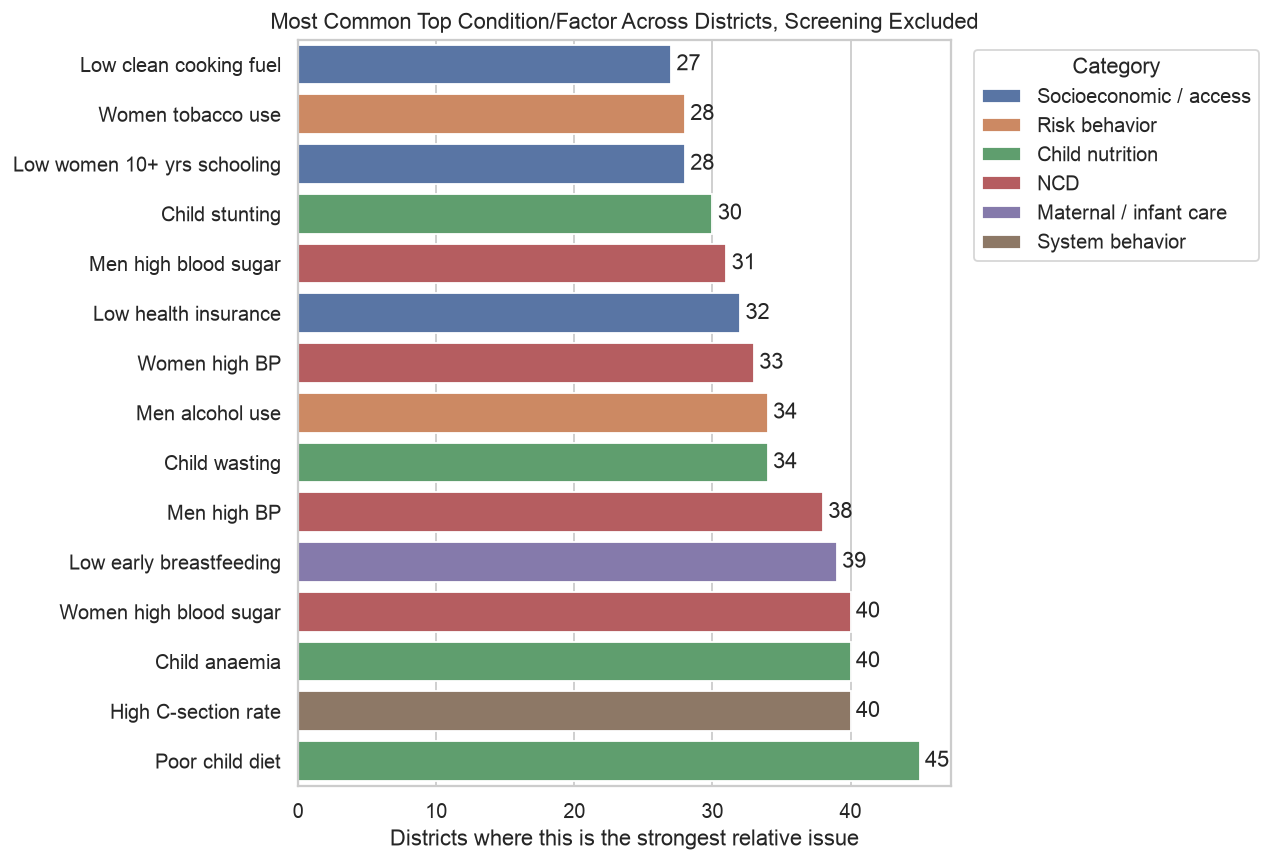

In [12]:
top_condition_counts = (
    top_conditions_by_district["top_condition_or_factor"]
    .value_counts()
    .rename_axis("condition_or_factor")
    .reset_index(name="districts")
)
top_condition_counts["category"] = top_condition_counts["condition_or_factor"].map(
    spec_df.set_index("condition")["category"]
)

fig, ax = plt.subplots(figsize=(10, 6.8))
plot_counts = top_condition_counts.head(15).sort_values("districts", ascending=True)
sns.barplot(
    data=plot_counts,
    y="condition_or_factor",
    x="districts",
    hue="category",
    dodge=False,
    ax=ax,
)
ax.set_title("Most Common Top Condition/Factor Across Districts, Screening Excluded")
ax.set_xlabel("Districts where this is the strongest relative issue")
ax.set_ylabel("")
ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
for container in ax.containers:
    ax.bar_label(container, padding=3, fmt="%d")
plt.tight_layout()
plt.show()


## 8. Regional disparity and aggregate impact proxy

The more useful signal is not just "what is bad on average"; it is where
district values vary enough to guide targeted deployment. This section
ranks indicators by p90-p10 spread, then computes a non-causal impact
proxy:

`impact_proxy = mean(district burden_or_gap_percent * district severity_percentile)`

Preventive screening is intentionally excluded from this blended proxy and
should be tracked separately as a screening-specific program opportunity.


In [13]:
disparity_rows = []
for spec in condition_specs:
    label = spec["condition"]
    raw = health[spec["column"]]
    burden = burden_matrix[label]
    severity = severity_matrix[label]
    disparity_rows.append(
        {
            "condition_or_factor": label,
            "category": spec["category"],
            "direction": spec["direction"],
            "mean": raw.mean(),
            "median": raw.median(),
            "p10": raw.quantile(0.10),
            "p90": raw.quantile(0.90),
            "p90_p10_spread": raw.quantile(0.90) - raw.quantile(0.10),
            "skew": raw.skew(),
            "excess_kurtosis": raw.kurt(),
            "mean_burden_or_gap_pct": burden.mean(),
            "p90_burden_or_gap_pct": burden.quantile(0.90),
            "districts_top_issue": int((top_conditions_by_district["top_condition_or_factor"] == label).sum()),
            "impact_proxy": (burden * severity).mean(),
        }
    )

disparity_summary = pd.DataFrame(disparity_rows)
impact_summary = disparity_summary.sort_values("impact_proxy", ascending=False).reset_index(drop=True)
impact_summary["rank"] = np.arange(1, len(impact_summary) + 1)

display(
    disparity_summary.sort_values("p90_p10_spread", ascending=False)
    .head(15)
    .style.format(
        {
            "mean": "{:.1f}",
            "median": "{:.1f}",
            "p10": "{:.1f}",
            "p90": "{:.1f}",
            "p90_p10_spread": "{:.1f}",
            "skew": "{:.2f}",
            "excess_kurtosis": "{:.2f}",
        }
    )
)


,condition_or_factor,category,direction,mean,median,p10,p90,p90_p10_spread,skew,excess_kurtosis,mean_burden_or_gap_pct,p90_burden_or_gap_pct,districts_top_issue,impact_proxy
0,Rotavirus vaccination gap,Child immunization,low_bad,40.7,43.6,0.8,81.6,80.8,0.06,-1.45,59.270499,99.200000,11,38.692233
21,Low clean cooking fuel,Socioeconomic / access,low_bad,54.1,50.5,24.1,89.0,64.8,0.22,-1.16,45.876912,75.900000,27,29.912998
20,Low health insurance,Socioeconomic / access,low_bad,40.2,35.7,13.2,72.2,58.9,0.45,-0.88,59.770822,86.750000,32,36.483657
7,Low 4+ ANC visits,Maternal access,low_bad,60.5,62.5,32.8,87.6,54.8,-0.25,-0.69,39.527660,67.220000,23,25.589653
10,Low early breastfeeding,Maternal / infant care,low_bad,44.8,45.1,23.0,65.4,42.4,0.08,-0.56,55.200993,76.960000,39,32.276266
11,High C-section rate,System behavior,high_bad,22.8,18.6,6.5,46.8,40.2,1.15,0.94,22.842351,46.800000,40,15.734079
17,Men tobacco use,Risk behavior,high_bad,40.6,42.5,20.6,56.9,36.3,-0.16,-0.50,40.591926,56.900000,19,24.325765
22,Low improved sanitation,Socioeconomic / access,low_bad,71.9,73.8,52.5,88.5,35.9,-0.47,-0.28,28.067847,47.450000,25,18.085197
23,Low women 10+ yrs schooling,Socioeconomic / access,low_bad,40.3,39.2,23.0,58.8,35.8,0.54,0.03,59.673229,77.000000,28,33.880309
19,Men alcohol use,Risk behavior,high_bad,23.2,20.1,9.2,42.9,33.6,0.83,0.32,23.195184,42.900000,34,15.297316


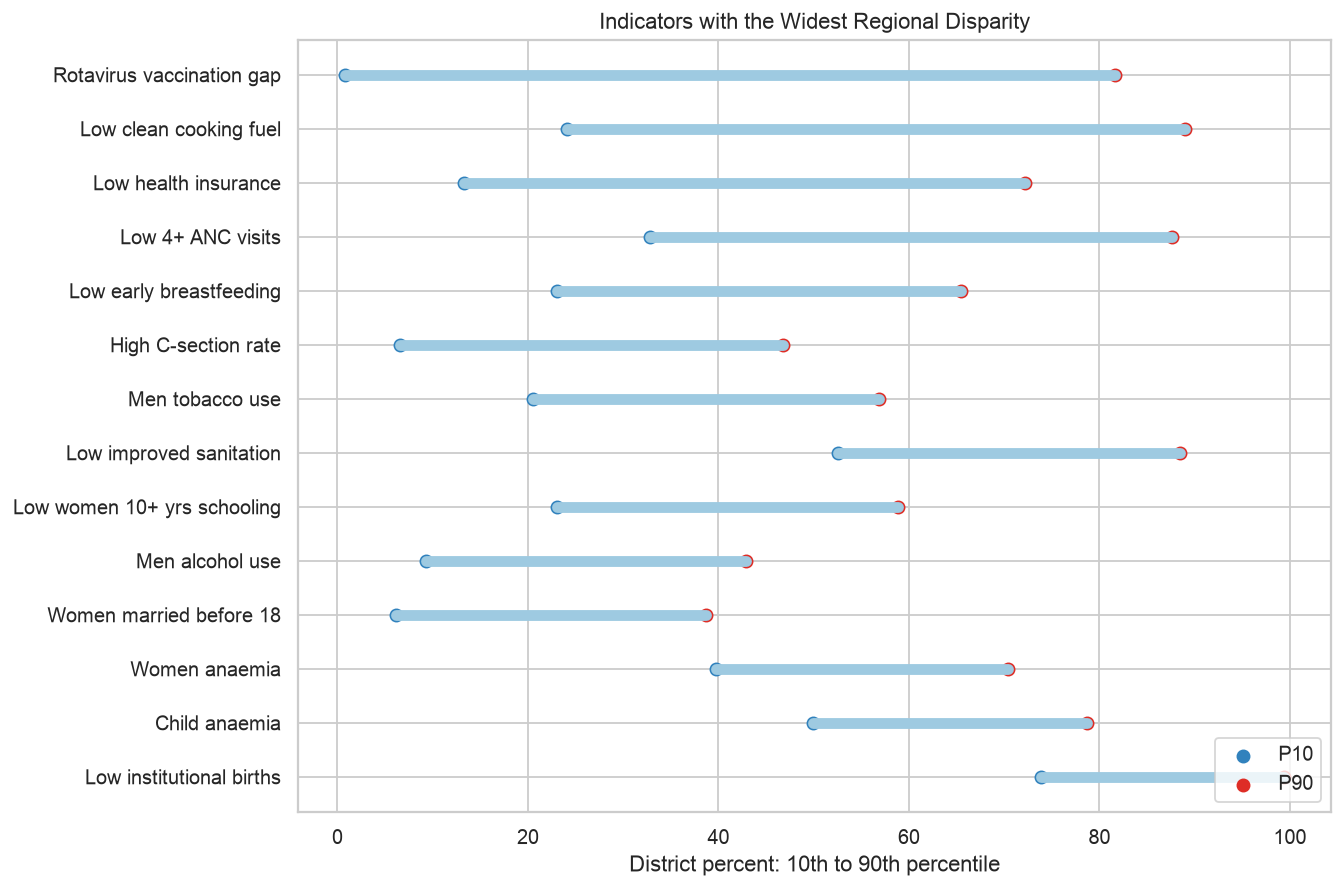

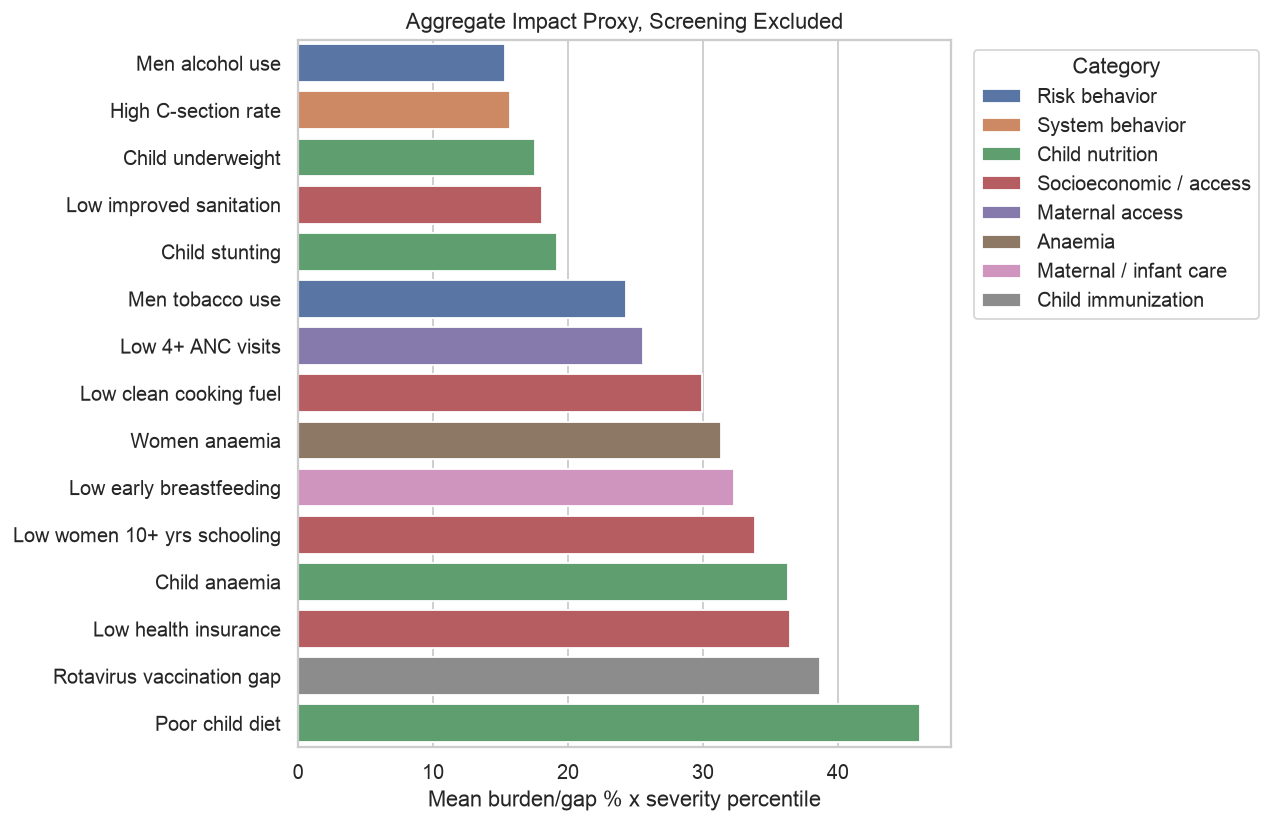

In [14]:
spread_plot = disparity_summary.sort_values("p90_p10_spread", ascending=False).head(14).copy()
spread_plot = spread_plot.sort_values("p90_p10_spread", ascending=True)

fig, ax = plt.subplots(figsize=(10.5, 7.0))
for _, row in spread_plot.iterrows():
    ax.plot([row["p10"], row["p90"]], [row["condition_or_factor"], row["condition_or_factor"]], color="#9ecae1", linewidth=6)
    ax.scatter(row["p10"], row["condition_or_factor"], color="#3182bd", s=45, label="P10" if "P10" not in ax.get_legend_handles_labels()[1] else "")
    ax.scatter(row["p90"], row["condition_or_factor"], color="#de2d26", s=45, label="P90" if "P90" not in ax.get_legend_handles_labels()[1] else "")
ax.set_title("Indicators with the Widest Regional Disparity")
ax.set_xlabel("District percent: 10th to 90th percentile")
ax.set_ylabel("")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6.5))
impact_plot = impact_summary.head(15).sort_values("impact_proxy", ascending=True)
sns.barplot(
    data=impact_plot,
    y="condition_or_factor",
    x="impact_proxy",
    hue="category",
    dodge=False,
    ax=ax,
)
ax.set_title("Aggregate Impact Proxy, Screening Excluded")
ax.set_xlabel("Mean burden/gap % x severity percentile")
ax.set_ylabel("")
ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


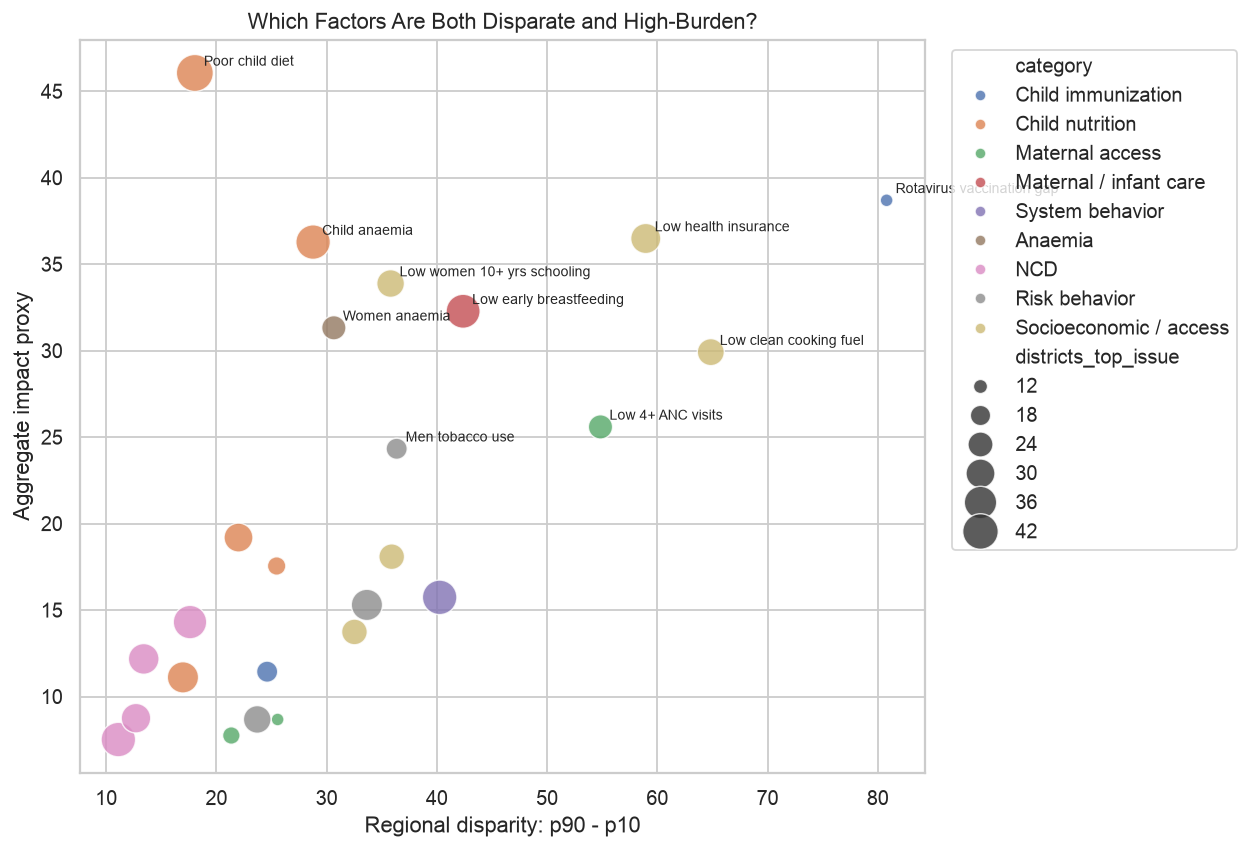

In [15]:
fig, ax = plt.subplots(figsize=(9.8, 6.7))
sns.scatterplot(
    data=disparity_summary,
    x="p90_p10_spread",
    y="impact_proxy",
    size="districts_top_issue",
    hue="category",
    sizes=(50, 420),
    alpha=0.80,
    ax=ax,
)
ax.set_title("Which Factors Are Both Disparate and High-Burden?")
ax.set_xlabel("Regional disparity: p90 - p10")
ax.set_ylabel("Aggregate impact proxy")

for _, row in disparity_summary.sort_values(["impact_proxy", "p90_p10_spread"], ascending=False).head(10).iterrows():
    ax.annotate(
        row["condition_or_factor"],
        (row["p90_p10_spread"], row["impact_proxy"]),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=8,
    )

ax.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 9. Distribution shapes: Gaussian or not?

Most useful fields here are not Gaussian. Many are bounded percentages
with ceiling effects, floor effects, rollout cliffs, or right tails.
That is exactly why percentile scoring and lane-specific interpretation
work better than z-scores or a single linear blended score.


In [16]:
from statistics import NormalDist

distribution_cols = {
    "Rotavirus vaccination": "child_12_23m_who_have_received_3_doses_of_rotavirus_vaccine_pct",
    "Clean cooking fuel": "households_using_clean_fuel_for_cooking_pct",
    "Health insurance": "hh_member_covered_health_insurance_pct",
    "4+ ANC visits": "mothers_who_had_at_least_4_anc_visits_lb5y_pct",
    "C-section deliveries": "births_delivered_by_csection_5y_pct",
    "Men tobacco": "m15_plus_who_use_any_kind_of_tobacco_pct",
    "Women 10+ years schooling": "women_age_15_49_with_10_or_more_years_of_schooling_pct",
    "Early breastfeeding": "children_under_age_3_years_breastfed_within_one_hour_of_bir_pct",
    "Women anaemia": "all_w15_49_who_are_anaemic_pct",
    "Adequate child diet": "total_child_6_23m_receiving_an_adequate_diet16_17_pct",
    "Institutional births": "institutional_birth_5y_pct",
    "Health-need score": "health_need_score",
}

dist_rows = []
for label, col in distribution_cols.items():
    x = health[col].dropna()
    n = len(x)
    skew = x.skew()
    excess_kurtosis = x.kurt()
    jb_stat = (n / 6) * (skew**2 + (excess_kurtosis**2 / 4))
    jb_pvalue_proxy = np.exp(-jb_stat / 2)
    if abs(skew) < 0.5:
        shape = "roughly symmetric"
    elif skew > 0.5:
        shape = "right-skewed"
    else:
        shape = "left-skewed / ceiling-heavy"
    if excess_kurtosis > 1:
        shape += "; heavy-tailed/peaked"
    if excess_kurtosis < -1:
        shape += "; flat or bimodal-looking"
    dist_rows.append(
        {
            "indicator": label,
            "n": n,
            "mean": x.mean(),
            "median": x.median(),
            "std": x.std(),
            "p10": x.quantile(0.10),
            "p90": x.quantile(0.90),
            "skew": skew,
            "excess_kurtosis": excess_kurtosis,
            "jb_pvalue_proxy": jb_pvalue_proxy,
            "shape_read": shape,
        }
    )

distribution_summary = pd.DataFrame(dist_rows).sort_values("jb_pvalue_proxy")
display(
    distribution_summary.style.format(
        {
            "mean": "{:.1f}",
            "median": "{:.1f}",
            "std": "{:.1f}",
            "p10": "{:.1f}",
            "p90": "{:.1f}",
            "skew": "{:.2f}",
            "excess_kurtosis": "{:.2f}",
            "jb_pvalue_proxy": "{:.2e}",
        }
    )
)


,indicator,n,mean,median,std,p10,p90,skew,excess_kurtosis,jb_pvalue_proxy,shape_read
10,Institutional births,706,88.7,92.2,12.0,73.8,99.4,-1.96,5.07,9.13e-263,left-skewed / ceiling-heavy; heavy-tailed/peaked
4,C-section deliveries,706,22.8,18.6,16.0,6.5,46.8,1.15,0.94,2.04e-40,right-skewed
9,Adequate child diet,654,11.9,10.6,7.1,4.0,22.0,0.91,0.81,2.86e-24,right-skewed
2,Health insurance,706,40.2,35.7,23.1,13.2,72.2,0.45,-0.88,6.62e-11,roughly symmetric
1,Clean cooking fuel,706,54.1,50.5,24.2,24.1,89.0,0.22,-1.16,1.76e-10,roughly symmetric; flat or bimodal-looking
0,Rotavirus vaccination,461,40.7,43.6,31.5,0.8,81.6,0.06,-1.45,1.66e-09,roughly symmetric; flat or bimodal-looking
6,Women 10+ years schooling,706,40.3,39.2,14.2,23.0,58.8,0.54,0.03,4.25e-08,right-skewed
8,Women anaemia,706,55.9,57.2,11.9,39.8,70.4,-0.40,0.29,2.19e-05,roughly symmetric
3,4+ ANC visits,705,60.5,62.5,20.3,32.8,87.6,-0.25,-0.69,2.25e-05,roughly symmetric
5,Men tobacco,706,40.6,42.5,14.1,20.6,56.9,-0.16,-0.50,5.37e-03,roughly symmetric


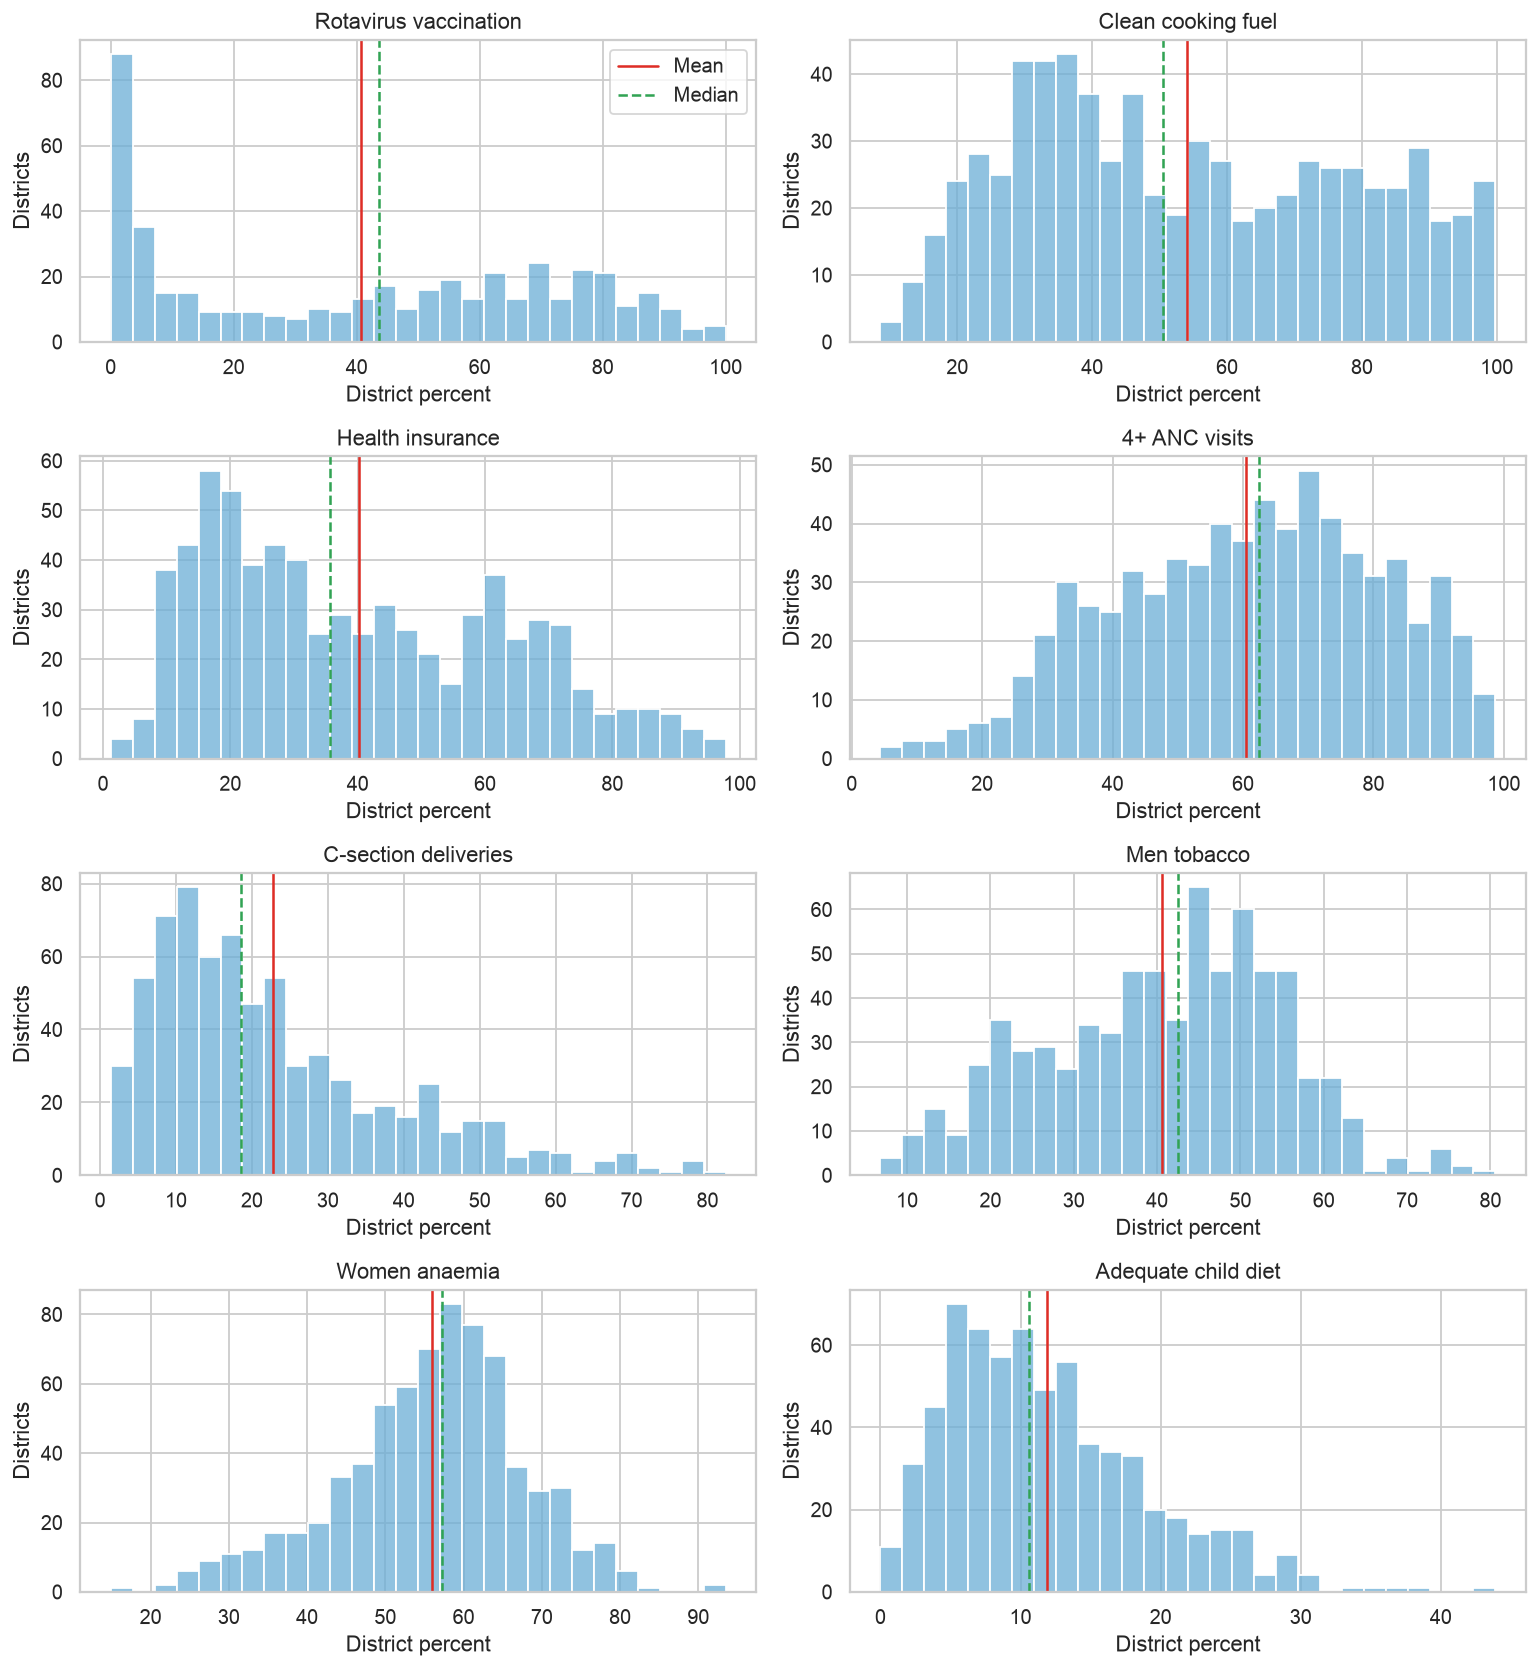

In [17]:
hist_cols = [
    "Rotavirus vaccination",
    "Clean cooking fuel",
    "Health insurance",
    "4+ ANC visits",
    "C-section deliveries",
    "Men tobacco",
    "Women anaemia",
    "Adequate child diet",
]

fig, axes = plt.subplots(4, 2, figsize=(12, 13))
for ax, label in zip(axes.flat, hist_cols):
    values = health[distribution_cols[label]].dropna()
    sns.histplot(values, bins=28, ax=ax, color="#6baed6")
    ax.axvline(values.mean(), color="#de2d26", linewidth=1.4, label="Mean")
    ax.axvline(values.median(), color="#31a354", linewidth=1.4, linestyle="--", label="Median")
    ax.set_title(label)
    ax.set_xlabel("District percent")
    ax.set_ylabel("Districts")
axes.flat[0].legend()
plt.tight_layout()
plt.show()


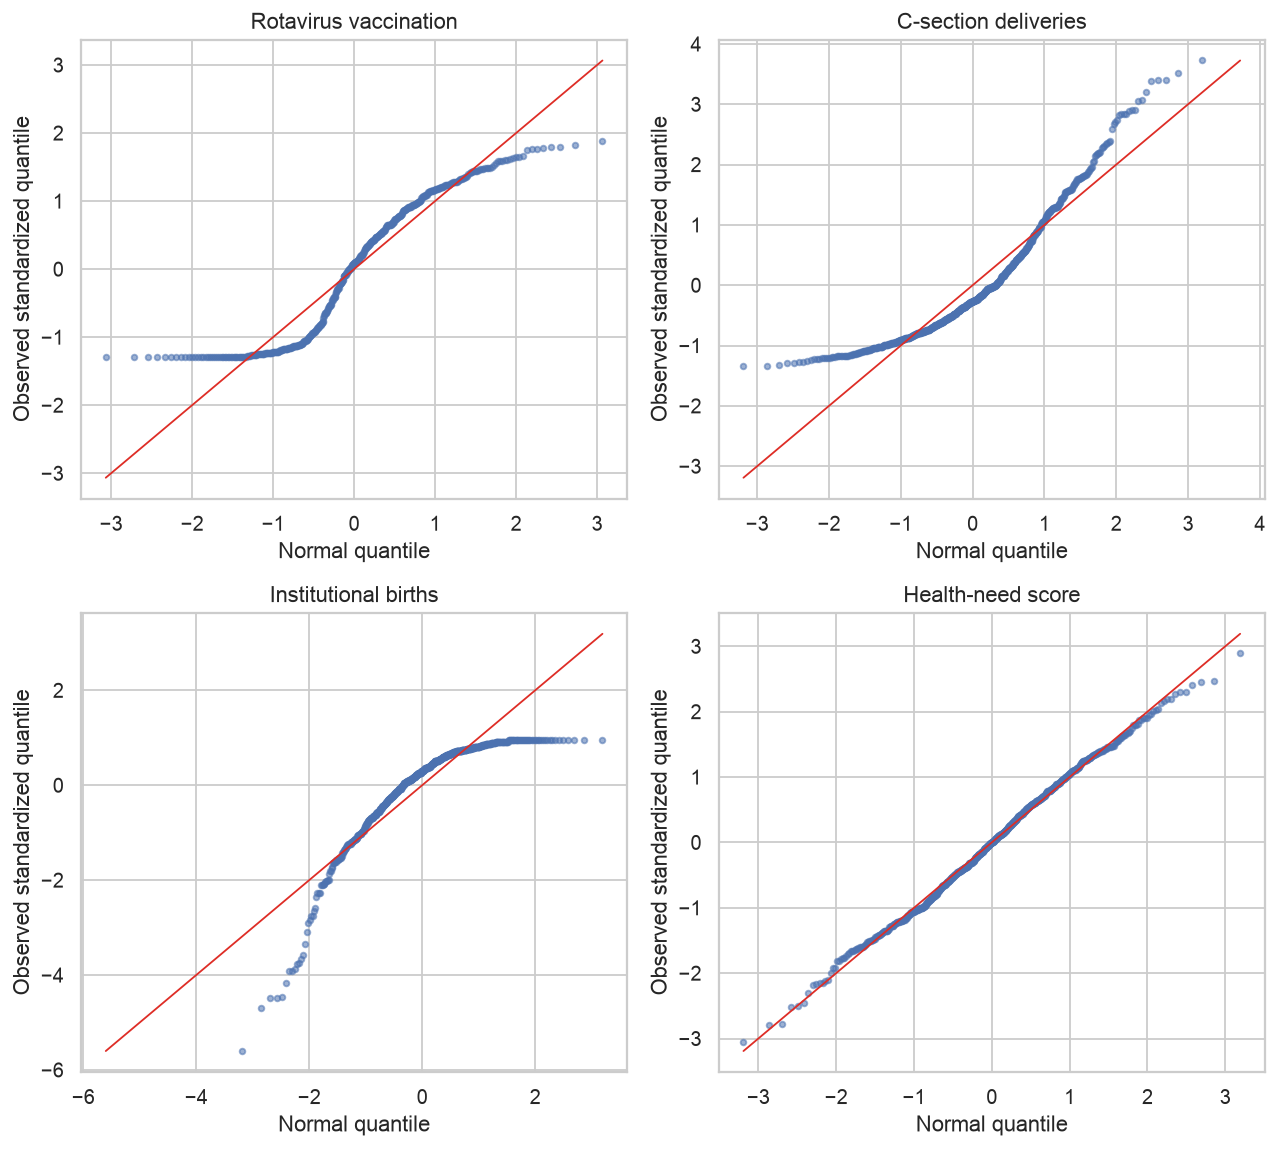

In [18]:
qq_targets = {
    "Rotavirus vaccination": "child_12_23m_who_have_received_3_doses_of_rotavirus_vaccine_pct",
    "C-section deliveries": "births_delivered_by_csection_5y_pct",
    "Institutional births": "institutional_birth_5y_pct",
    "Health-need score": "health_need_score",
}

normal = NormalDist()
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for ax, (label, col) in zip(axes.flat, qq_targets.items()):
    x = health[col].dropna().sort_values().to_numpy()
    n = len(x)
    probs = (np.arange(1, n + 1) - 0.5) / n
    theoretical = np.array([normal.inv_cdf(p) for p in probs])
    sample_z = (x - x.mean()) / x.std(ddof=1)
    ax.scatter(theoretical, sample_z, s=10, alpha=0.55)
    line_min = min(theoretical.min(), sample_z.min())
    line_max = max(theoretical.max(), sample_z.max())
    ax.plot([line_min, line_max], [line_min, line_max], color="#de2d26", linewidth=1)
    ax.set_title(label)
    ax.set_xlabel("Normal quantile")
    ax.set_ylabel("Observed standardized quantile")
plt.tight_layout()
plt.show()


## 10. Qualitative synthesis for doctors and resource planners

A doctor or field operations lead should read this dataset as a triage map,
not as a facility report card. The core question is: which districts have
a clear intervention profile, and what kind of team should go there?

The best deployment signals are the ones with both regional disparity and
intervention fit. Rotavirus vaccination gaps point to immunization catch-up
work. ANC and early breastfeeding gaps point to maternal/infant outreach.
Child diet, anaemia, and anthropometrics point to nutrition programs.
BP, glucose, tobacco, and alcohol point to chronic-care and behavior-risk
teams. Insurance, clean cooking fuel, sanitation, and schooling are not
clinical conditions, but they explain where care uptake may need social
support.


In [19]:
doctor_playbook = pd.DataFrame(
    [
        {
            "Priority lane": "Child immunization",
            "Signals": "Low rotavirus or full vaccination",
            "What doctors can infer": "Program rollout or uptake may be uneven; catch-up campaigns can be targeted.",
            "Resource response": "Vaccination camps, cold-chain planning, ASHA/CHW follow-up, defaulter lists.",
        },
        {
            "Priority lane": "Maternal / infant access",
            "Signals": "Low 4+ ANC, low institutional births, low skilled attendance, low early breastfeeding",
            "What doctors can infer": "Pregnancy and newborn care pathways may be weak or underused.",
            "Resource response": "ANC outreach, birth planning, referral transport, lactation support, public-facility linkage.",
        },
        {
            "Priority lane": "Child nutrition and anaemia",
            "Signals": "Poor child diet, stunting, wasting, underweight, child/women anaemia",
            "What doctors can infer": "Clinical burden likely requires nutrition and household follow-up, not only one-off treatment.",
            "Resource response": "Growth monitoring, nutrition counseling, anaemia testing, iron/folate linkage, pediatric follow-up.",
        },
        {
            "Priority lane": "NCD and behavior risk",
            "Signals": "High BP, high blood sugar, tobacco, alcohol",
            "What doctors can infer": "Screening is useful only if paired with continuity and medication/referral pathways.",
            "Resource response": "BP/glucose camps, chronic-care registries, medication stock, cessation counseling, referral partners.",
        },
        {
            "Priority lane": "Structural access barriers",
            "Signals": "Low insurance, low clean fuel, low sanitation, low female schooling",
            "What doctors can infer": "Adherence and uptake may be constrained by non-clinical barriers.",
            "Resource response": "Benefits navigation, local NGO/government partners, health education, longer follow-up cadence.",
        },
    ]
)
display(doctor_playbook)

priority_lane_specs = [
    {"lane": "Rotavirus gap", "column": "child_12_23m_who_have_received_3_doses_of_rotavirus_vaccine_pct", "direction": "low_bad"},
    {"lane": "Clean fuel gap", "column": "households_using_clean_fuel_for_cooking_pct", "direction": "low_bad"},
    {"lane": "Insurance gap", "column": "hh_member_covered_health_insurance_pct", "direction": "low_bad"},
    {"lane": "4+ ANC gap", "column": "mothers_who_had_at_least_4_anc_visits_lb5y_pct", "direction": "low_bad"},
    {"lane": "Early breastfeeding gap", "column": "children_under_age_3_years_breastfed_within_one_hour_of_bir_pct", "direction": "low_bad"},
    {"lane": "High C-section", "column": "births_delivered_by_csection_5y_pct", "direction": "high_bad"},
    {"lane": "Men tobacco", "column": "m15_plus_who_use_any_kind_of_tobacco_pct", "direction": "high_bad"},
    {"lane": "Low women schooling", "column": "women_age_15_49_with_10_or_more_years_of_schooling_pct", "direction": "low_bad"},
    {"lane": "Women anaemia", "column": "all_w15_49_who_are_anaemic_pct", "direction": "high_bad"},
    {"lane": "Poor child diet", "column": "total_child_6_23m_receiving_an_adequate_diet16_17_pct", "direction": "low_bad"},
]

lane_values = pd.DataFrame(index=health.index)
lane_severity = pd.DataFrame(index=health.index)
for spec in priority_lane_specs:
    raw = health[spec["column"]]
    if spec["direction"] == "high_bad":
        burden = raw
        severity = raw.rank(pct=True)
    else:
        burden = (100 - raw).clip(lower=0, upper=100)
        severity = (-raw).rank(pct=True)
    lane_values[spec["lane"]] = burden
    lane_severity[spec["lane"]] = severity

lane_priority = health[["district_clean", "state_clean", "health_need_score"]].copy()
lane_priority["high_disparity_priority_score"] = (
    0.55 * lane_severity.mean(axis=1)
    + 0.30 * health["health_need_score"]
    + 0.15 * lane_severity.max(axis=1)
)
lane_priority["top_lane"] = lane_severity.idxmax(axis=1)
lane_priority["top_lane_burden_or_gap_pct"] = [
    lane_values.loc[idx, lane] for idx, lane in lane_priority["top_lane"].items()
]

display(
    lane_priority.sort_values("high_disparity_priority_score", ascending=False)
    .head(25)
    .style.format(
        {
            "health_need_score": "{:.3f}",
            "high_disparity_priority_score": "{:.3f}",
            "top_lane_burden_or_gap_pct": "{:.1f}",
        }
    )
)


,Priority lane,Signals,What doctors can infer,Resource response
0,Child immunization,Low rotavirus or full vaccination,Program rollout or uptake may be uneven; catch...,"Vaccination camps, cold-chain planning, ASHA/C..."
1,Maternal / infant access,"Low 4+ ANC, low institutional births, low skil...",Pregnancy and newborn care pathways may be wea...,"ANC outreach, birth planning, referral transpo..."
2,Child nutrition and anaemia,"Poor child diet, stunting, wasting, underweigh...",Clinical burden likely requires nutrition and ...,"Growth monitoring, nutrition counseling, anaem..."
3,NCD and behavior risk,"High BP, high blood sugar, tobacco, alcohol",Screening is useful only if paired with contin...,"BP/glucose camps, chronic-care registries, med..."
4,Structural access barriers,"Low insurance, low clean fuel, low sanitation,...",Adherence and uptake may be constrained by non...,"Benefits navigation, local NGO/government part..."


,district_clean,state_clean,health_need_score,high_disparity_priority_score,top_lane,top_lane_burden_or_gap_pct
78,Katihar,Bihar,0.770,0.792,4+ ANC gap,84.7
76,Kishanganj,Bihar,0.675,0.789,Low women schooling,85.0
104,Jamui,Bihar,0.701,0.782,Women anaemia,75.2
77,Purnia,Bihar,0.628,0.774,4+ ANC gap,88.9
79,Madhepura,Bihar,0.636,0.771,Clean fuel gap,86.6
80,Saharsa,Bihar,0.675,0.765,4+ ANC gap,88.3
597,Unakoti,Tripura,0.725,0.765,Low women schooling,81.3
91,Banka,Bihar,0.688,0.763,Poor child diet,97.2
95,Nalanda,Bihar,0.633,0.759,Rotavirus gap,100.0
165,Kheda,Gujarat,0.715,0.757,Poor child diet,98.8


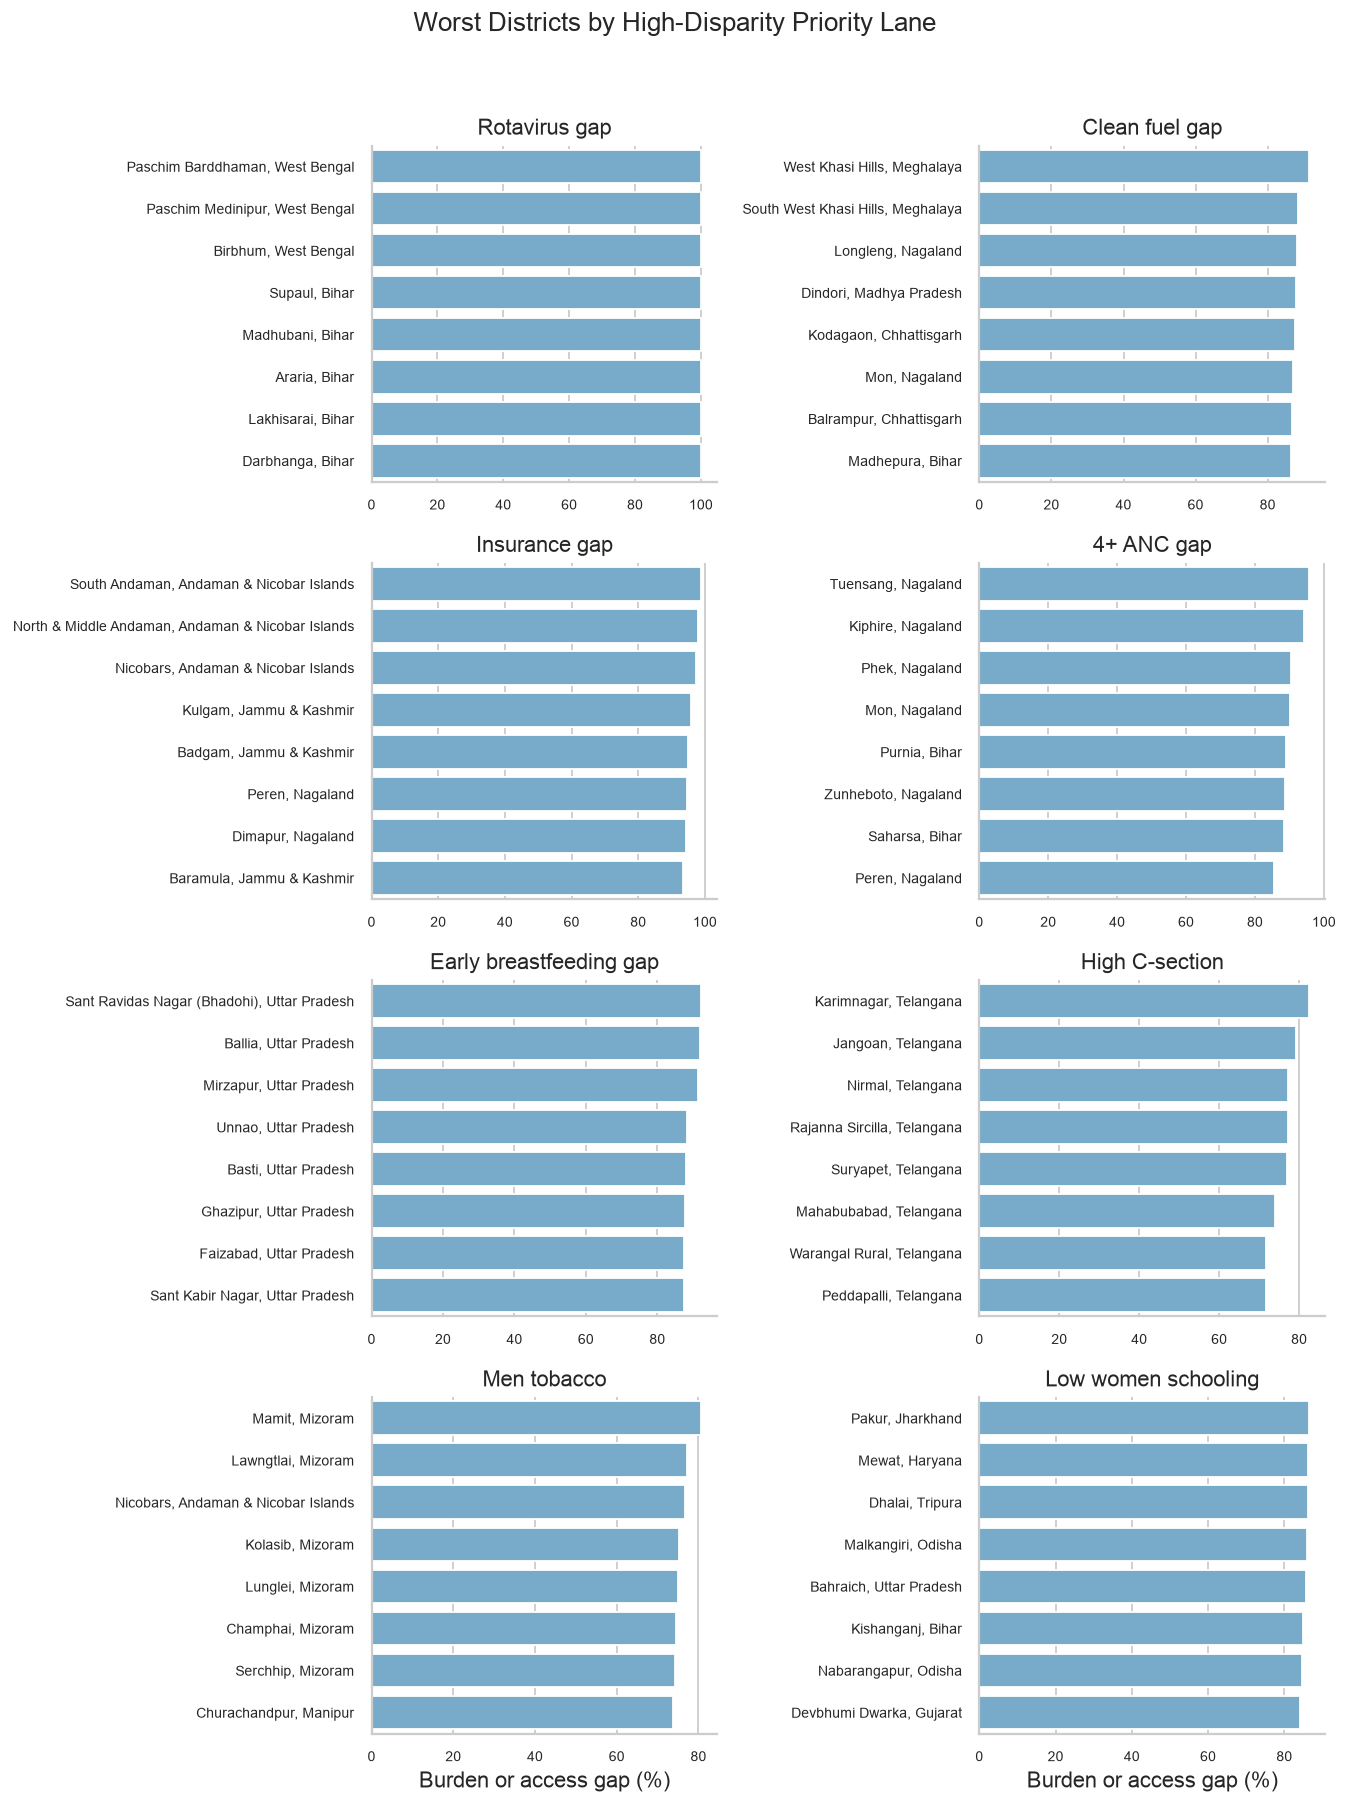

In [20]:
worst_by_lane_frames = []
for spec in priority_lane_specs[:8]:
    lane = spec["lane"]
    top = health[["district_clean", "state_clean"]].copy()
    top["lane"] = lane
    top["burden_or_gap_pct"] = lane_values[lane]
    top["severity_percentile"] = lane_severity[lane]
    top["district_label"] = top["district_clean"] + ", " + top["state_clean"]
    worst_by_lane_frames.append(top.sort_values("severity_percentile", ascending=False).head(8))
worst_by_lane = pd.concat(worst_by_lane_frames, ignore_index=True)

g = sns.FacetGrid(
    worst_by_lane,
    col="lane",
    col_wrap=2,
    sharex=False,
    sharey=False,
    height=3.4,
    aspect=1.55,
)
g.map_dataframe(
    sns.barplot,
    y="district_label",
    x="burden_or_gap_pct",
    color="#6baed6",
    order=None,
)
g.set_titles("{col_name}")
g.set_axis_labels("Burden or access gap (%)", "")
for ax in g.axes.flat:
    ax.tick_params(axis="y", labelsize=8)
    ax.tick_params(axis="x", labelsize=8)
g.fig.suptitle("Worst Districts by High-Disparity Priority Lane", y=1.02)
plt.tight_layout()
plt.show()


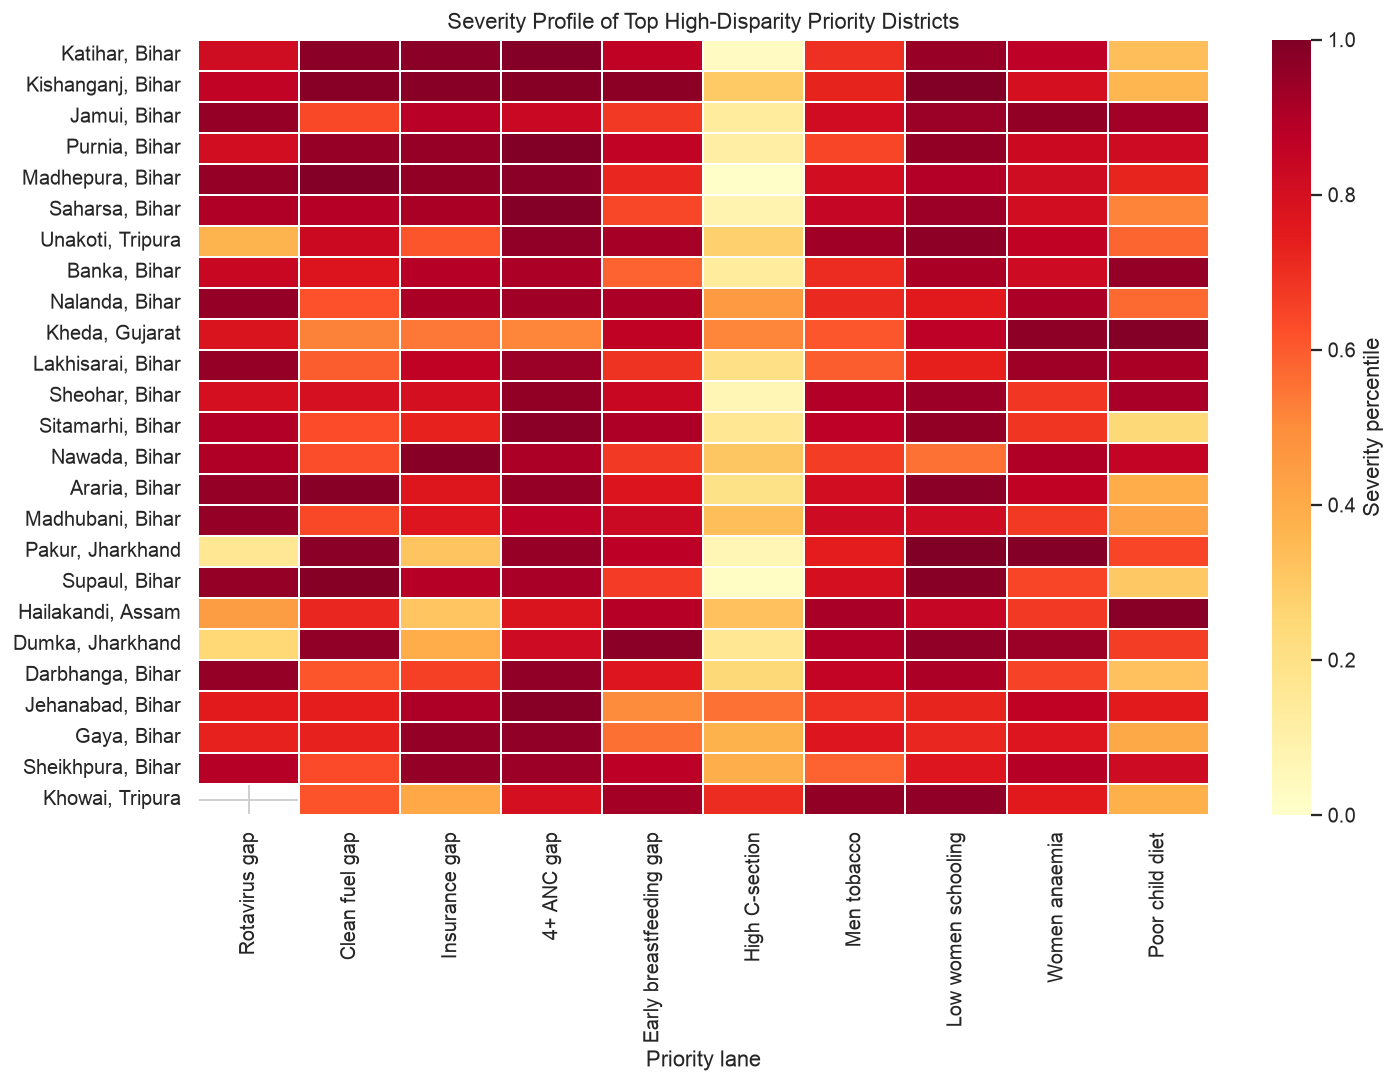

In [21]:
heatmap_districts = lane_priority.sort_values("high_disparity_priority_score", ascending=False).head(25)
heatmap_labels = heatmap_districts["district_clean"] + ", " + heatmap_districts["state_clean"]
heatmap_scores = lane_severity.loc[heatmap_districts.index, [spec["lane"] for spec in priority_lane_specs]]
heatmap_scores.index = heatmap_labels

fig, ax = plt.subplots(figsize=(11.5, 8.5))
sns.heatmap(
    heatmap_scores,
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    linewidths=0.25,
    cbar_kws={"label": "Severity percentile"},
    ax=ax,
)
ax.set_title("Severity Profile of Top High-Disparity Priority Districts")
ax.set_xlabel("Priority lane")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## 11. Takeaways for the hackathon app

- Treat NFHS indicators as district context, never as facility facts.
- Keep preventive screening as a separate outreach lane; do not let it
  dominate a blended district priority score.
- Use lane-specific priorities: child immunization/nutrition, maternal
  access, NCDs, behavior risk, and structural access barriers.
- Use percentile-based scoring because the distributions are bounded,
  skewed, ceiling-heavy, floor-heavy, or rollout-like rather than Gaussian.
- Preserve `join_strategy`, `join_confidence`, and `join_uncertainty_reason`
  wherever facility rankings or recommendations use district health context.
- Build or import a state/district crosswalk before using the table in
  production-like flows.
